In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata
from difflib import SequenceMatcher

BASE_DIR = Path("/Users/joshmacbook/python_projects/OAD/Data/in Use")

# INPUTS
RAW_2026_PATH = "/Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues/2026_small.csv"
ODDS_XLSX_PATH = BASE_DIR / "Odds_and_Results.xlsx"
SCHEDULE_2026_PATH = BASE_DIR / "OAD_2026.xlsx"   # optional, but recommended

# OUTPUT
OUT = Path("/Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues")
OUT_PATH = OUT / "2026_small_normalized.csv"

SEASON = 2026
LEAGUE_ID = "2026_small"

_SUFFIXES = {"jr", "sr", "ii", "iii", "iv", "v"}

def _strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

def norm_name(s: str) -> str:
    """Normalize names for matching: lowercase, strip accents/punct, drop suffixes."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip()
    s = _strip_accents(s)
    s = s.replace("’", "'").lower()

    # punctuation to space (comma handled too)
    s = re.sub(r"[^a-z0-9,\s\-']", " ", s)
    s = s.replace("-", " ").replace("'", "").replace(",", " ")
    s = re.sub(r"\s+", " ", s).strip()

    parts = s.split()
    while parts and parts[-1] in _SUFFIXES:
        parts = parts[:-1]
    return " ".join(parts).strip()

def seq_ratio(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()

def make_event_key(event_name: str, event_date) -> str:
    dt = pd.to_datetime(event_date).date()
    return f"{event_name}_{dt:%Y-%m-%d}"

def to_first_last_from_last_first(raw: str) -> str:
    """Convert 'Last, First' -> 'First Last' (best-effort)."""
    s = str(raw)
    if "," in s:
        last, first = [x.strip() for x in s.split(",", 1)]
        return f"{first} {last}".strip()
    return s

def to_last_first_from_first_last(raw: str, last_tokens: int = 1) -> str:
    """
    Convert 'First Middle Last' -> 'Last, First Middle'
    with a variable # of last-name tokens (1..3).
    """
    parts = norm_name(raw).split()
    if len(parts) < 2:
        return raw
    last = " ".join(parts[-last_tokens:])
    first = " ".join(parts[:-last_tokens])
    return f"{last}, {first}".strip()


In [4]:
df_raw = pd.read_csv(RAW_2026_PATH)
print("Raw columns:", df_raw.columns.tolist())
display(df_raw.head(5))

# Accept both variants:
# (A) C1..C6
# (B) username/entryId/eventName/eventDate/selection/winnings

rename = {
    "C1": "username",
    "C2": "entry_id",
    "C3": "event_name",
    "C4": "event_date",
    "C5": "player_name",
    "C6": "raw_winnings",
    "entryId": "entry_id",
    "eventName": "event_name",
    "eventDate": "event_date",
    "selection": "player_name",
    "winnings": "raw_winnings",
}
df = df_raw.rename(columns={k:v for k,v in rename.items() if k in df_raw.columns}).copy()

need = ["username", "entry_id", "event_name", "event_date", "player_name", "raw_winnings"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Have: {df.columns.tolist()}")

df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["raw_winnings"] = pd.to_numeric(df["raw_winnings"], errors="coerce")

df_out = pd.DataFrame({
    "season": SEASON,
    "league_id": LEAGUE_ID,
    "event_name": df["event_name"].astype(str),
    "event_date": df["event_date"],
    "event_key": df.apply(lambda r: make_event_key(str(r["event_name"]), r["event_date"]), axis=1),
    "entry_id": df["entry_id"].astype(str),
    "username": df["username"].astype(str),
    "player_name": df["player_name"].astype(str),
    "dg_id": pd.NA,
    "raw_winnings": df["raw_winnings"],
})

display(df_out.head(5))
print("Rows:", len(df_out))


Raw columns: ['season', 'username', 'entryId', 'event_name', 'eventDate', 'selection', 'winnings']


,season,username,entryId,event_name,eventDate,selection,winnings
0,2026,ADmun,m3h8gxx,Sony Open in Hawaii,2026-01-15,Nicolas Echavarria,0
1,2026,AKsREVENGE,oohwwvx,Sony Open in Hawaii,2026-01-15,J.J. Spaun,31522
2,2026,andylicious,78ho83z,Sony Open in Hawaii,2026-01-15,Robert MacIntyre,409500
3,2026,balvari,0dh4357,Sony Open in Hawaii,2026-01-15,Corey Conners,72475
4,2026,Bdavis7916,k6hyezx,Sony Open in Hawaii,2026-01-15,Keegan Bradley,0


,season,league_id,event_name,event_date,event_key,entry_id,username,player_name,dg_id,raw_winnings
0,2026,2026_small,Sony Open in Hawaii,2026-01-15,Sony Open in Hawaii_2026-01-15,m3h8gxx,ADmun,Nicolas Echavarria,<NA>,0
1,2026,2026_small,Sony Open in Hawaii,2026-01-15,Sony Open in Hawaii_2026-01-15,oohwwvx,AKsREVENGE,J.J. Spaun,<NA>,31522
2,2026,2026_small,Sony Open in Hawaii,2026-01-15,Sony Open in Hawaii_2026-01-15,78ho83z,andylicious,Robert MacIntyre,<NA>,409500
3,2026,2026_small,Sony Open in Hawaii,2026-01-15,Sony Open in Hawaii_2026-01-15,0dh4357,balvari,Corey Conners,<NA>,72475
4,2026,2026_small,Sony Open in Hawaii,2026-01-15,Sony Open in Hawaii_2026-01-15,k6hyezx,Bdavis7916,Keegan Bradley,<NA>,0


Rows: 98


In [5]:
df_out["event_name_key"] = df_out["event_name"].apply(norm_name)

try:
    sched = pd.read_excel(SCHEDULE_2026_PATH)
    print("Schedule cols:", sched.columns.tolist())

    # Normalize schedule name/date columns
    if "start_date" in sched.columns:
        sched["start_date"] = pd.to_datetime(sched["start_date"], errors="coerce")
    elif "event_date" in sched.columns:
        sched["start_date"] = pd.to_datetime(sched["event_date"], errors="coerce")
    else:
        sched["start_date"] = pd.NaT

    if "event_name" not in sched.columns:
        # if your schedule uses a different name col, adjust here
        raise ValueError("Schedule missing 'event_name' column (adjust this cell).")

    if "event_id" not in sched.columns:
        raise ValueError("Schedule missing 'event_id' column (adjust this cell).")

    sched["event_name_key"] = sched["event_name"].astype(str).apply(norm_name)

    tmp = df_out.merge(
        sched[["event_id", "event_name_key", "start_date"]],
        on="event_name_key",
        how="left",
    )

    # tie-break: closest date between df_out.event_date and schedule start_date
    tmp["date_diff"] = (tmp["event_date"] - tmp["start_date"]).abs()
    tmp = tmp.sort_values(["username", "entry_id", "event_date", "date_diff"])
    tmp = tmp.groupby(["username", "entry_id", "event_date", "event_name", "player_name"], as_index=False).first()

    df_out = tmp.drop(columns=["start_date", "date_diff"])
    print("Attached event_id to picks. Sample:")
    display(df_out[["event_name", "event_date", "event_id"]].drop_duplicates().head(10))

except Exception as e:
    print("Schedule attach skipped (ok). Reason:", e)
    df_out["event_id"] = pd.NA


Schedule cols: ['year', 'start_date', 'event_name', 'purse', 'winner_share', 'event_id', 'course_name', 'course_num', 'rank']
Attached event_id to picks. Sample:


,event_name,event_date,event_id
0,Sony Open in Hawaii,2026-01-15,6.0
1,The American Express,2026-01-22,2.0


In [6]:
xl = pd.ExcelFile(ODDS_XLSX_PATH)
print("Sheets:", xl.sheet_names)

# Pick the first sheet that has dg_id + some name column
odds_df = None
for sh in xl.sheet_names:
    t = xl.parse(sh)
    cols = set([str(c).lower() for c in t.columns])
    if "dg_id" in cols and ("player_name" in cols or "player" in cols or "name" in cols):
        odds_df = t
        print("Using odds sheet:", sh)
        break

if odds_df is None:
    odds_df = xl.parse(xl.sheet_names[0])
    print("Fallback odds sheet:", xl.sheet_names[0])

odds_df = odds_df.rename(columns={c: str(c).lower() for c in odds_df.columns}).copy()

# Find name col
name_col = None
for cand in ["player_name", "player", "name"]:
    if cand in odds_df.columns:
        name_col = cand
        break
if name_col is None:
    raise ValueError(f"Could not find a player name column in odds. Columns: {odds_df.columns.tolist()}")

# Find year/season col
year_col = "year" if "year" in odds_df.columns else ("season" if "season" in odds_df.columns else None)
if year_col is None:
    raise ValueError("Odds is missing 'year' or 'season' column.")

odds_df[year_col] = pd.to_numeric(odds_df[year_col], errors="coerce").astype("Int64")
odds_df["event_id"] = pd.to_numeric(odds_df.get("event_id"), errors="coerce").astype("Int64")
odds_df["dg_id"] = pd.to_numeric(odds_df["dg_id"], errors="coerce").astype("Int64")

odds_df["player_raw"] = odds_df[name_col].astype(str)
odds_df["player_key_ff"] = odds_df["player_raw"].apply(to_first_last_from_last_first).apply(norm_name)
odds_df["player_key_raw"] = odds_df["player_raw"].apply(norm_name)

print("Odds rows:", len(odds_df))
display(odds_df[[year_col, "event_id", "player_raw", "dg_id"]].head(5))


Sheets: ['Sheet1', 'Sheet4']
Using odds sheet: Sheet1
Odds rows: 12401


,year,event_id,player_raw,dg_id
0,2023,6,"Echavarria, Nicolas",22833
1,2023,6,"Kim, Si Woo",14609
2,2023,6,"Buckley, Hayden",25363
3,2023,6,"Kirk, Chris",12423
4,2023,6,"Higa, Kazuki",15756


In [7]:
# Put any hard manual fixes here once you see the report (key should be norm_name("First Last"))
MANUAL_OVERRIDES = {
    # "ludvig aberg": 12345,
}

def match_dg_id(pick_name: str, odds_sub: pd.DataFrame, fuzzy_threshold: float = 0.92):
    """
    Return (dg_id, method, matched_to, score)
    method: manual / direct_ff / direct_raw / swap_lastN / fuzzy / unmatched / no_odds_rows
    """
    key = norm_name(pick_name)
    if not key:
        return None, "unmatched", None, 0.0

    if key in MANUAL_OVERRIDES:
        return int(MANUAL_OVERRIDES[key]), "manual", pick_name, 1.0

    sub = odds_sub.dropna(subset=["dg_id"]).copy()
    if sub.empty:
        return None, "no_odds_rows", None, 0.0

    map_ff = sub.drop_duplicates("player_key_ff").set_index("player_key_ff")["dg_id"].to_dict()
    map_raw = sub.drop_duplicates("player_key_raw").set_index("player_key_raw")["dg_id"].to_dict()

    if key in map_ff:
        return int(map_ff[key]), "direct_ff", pick_name, 1.0
    if key in map_raw:
        return int(map_raw[key]), "direct_raw", pick_name, 1.0

    # Try swap into last, first with 1..3 last-name tokens
    for n_last in [1, 2, 3]:
        lf = to_last_first_from_first_last(pick_name, last_tokens=n_last)
        k_lf = norm_name(lf)
        if k_lf in map_raw:
            return int(map_raw[k_lf]), f"swap_last{n_last}", lf, 1.0

    # Fuzzy within event/year
    candidates = sub[["player_raw", "player_key_ff", "dg_id"]].drop_duplicates()
    best = None
    best_sc = 0.0
    best_dg = None

    for _, row in candidates.iterrows():
        sc = seq_ratio(key, row["player_key_ff"])
        if sc > best_sc:
            best_sc = sc
            best = row["player_raw"]
            best_dg = row["dg_id"]

    if best is not None and best_sc >= fuzzy_threshold and pd.notna(best_dg):
        return int(best_dg), "fuzzy", best, float(best_sc)

    return None, "unmatched", best, float(best_sc)

report_rows = []
dg_ids = []

for _, r in df_out.iterrows():
    ev_id = r.get("event_id")
    pick = r["player_name"]

    if pd.notna(ev_id):
        odds_sub = odds_df[(odds_df[year_col] == SEASON) & (odds_df["event_id"] == int(ev_id))].copy()
    else:
        odds_sub = odds_df[(odds_df[year_col] == SEASON)].copy()

    dg, method, matched_to, score = match_dg_id(pick, odds_sub)
    dg_ids.append(dg)

    report_rows.append({
        "username": r["username"],
        "event_name": r["event_name"],
        "event_date": r["event_date"],
        "event_id": ev_id,
        "pick_player_name": pick,
        "dg_id": dg,
        "method": method,
        "matched_to_odds_name": matched_to,
        "score": score,
    })

df_out["dg_id"] = pd.Series(dg_ids, dtype="Int64")
match_report = pd.DataFrame(report_rows)

display(match_report["method"].value_counts())

# Show the problem cases
display(
    match_report[match_report["method"].isin(["unmatched", "fuzzy", "no_odds_rows"])]
    .sort_values(["event_date", "event_name", "method", "score"])
    .head(100)
)


method
direct_ff    96
unmatched     2
Name: count, dtype: int64

,username,event_name,event_date,event_id,pick_player_name,dg_id,method,matched_to_odds_name,score
0,ADmun,Sony Open in Hawaii,2026-01-15,6.0,Nicolas Echavarria,NaN,unmatched,"Echavarria, Nico",0.909091
12,Cjlemoin,Sony Open in Hawaii,2026-01-15,6.0,Nicolas Echavarria,NaN,unmatched,"Echavarria, Nico",0.909091


In [13]:
# Final cleanup: drop helper columns
if "event_name_key" in df_out.columns:
    df_out = df_out.drop(columns=["event_name_key"], errors="ignore")

df_out.to_csv(OUT_PATH, index=False)
print("Wrote:", OUT_PATH)

REPORT_PATH = OUT_PATH.with_name("2026_small_name_match_report.csv")
match_report.to_csv(REPORT_PATH, index=False)
print("Wrote:", REPORT_PATH)

# Quick sanity checks
print("Total rows:", len(df_out))
print("dg_id missing:", df_out["dg_id"].isna().sum())
display(df_out.head(10))


Wrote: /Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues/2026_small_normalized.csv
Wrote: /Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues/2026_small_name_match_report.csv
Total rows: 98
dg_id missing: 2


,username,entry_id,event_date,event_name,player_name,season,league_id,event_key,dg_id,raw_winnings,event_id
0,ADmun,m3h8gxx,2026-01-15,Sony Open in Hawaii,Nicolas Echavarria,2026,2026_small,Sony Open in Hawaii_2026-01-15,<NA>,0,6.0
1,ADmun,m3h8gxx,2026-01-22,The American Express,Sepp Straka,2026,2026_small,The American Express_2026-01-22,17511,0,2.0
2,AKsREVENGE,oohwwvx,2026-01-15,Sony Open in Hawaii,J.J. Spaun,2026,2026_small,Sony Open in Hawaii_2026-01-15,17536,31522,6.0
3,AKsREVENGE,oohwwvx,2026-01-22,The American Express,Robert MacIntyre,2026,2026_small,The American Express_2026-01-22,23323,39100,2.0
4,Bdavis7916,k6hyezx,2026-01-15,Sony Open in Hawaii,Keegan Bradley,2026,2026_small,Sony Open in Hawaii_2026-01-15,13872,0,6.0
5,Bdavis7916,k6hyezx,2026-01-22,The American Express,Harry Hall,2026,2026_small,The American Express_2026-01-22,27194,81420,2.0
6,BigBoKnows,53h0gr5,2026-01-15,Sony Open in Hawaii,Ryan Gerard,2026,2026_small,Sony Open in Hawaii_2026-01-15,29767,991900,6.0
7,BigBoKnows,53h0gr5,2026-01-22,The American Express,Pierceson Coody,2026,2026_small,The American Express_2026-01-22,28309,117607,2.0
8,BigCat97,8vh9q4n,2026-01-15,Sony Open in Hawaii,Russell Henley,2026,2026_small,Sony Open in Hawaii_2026-01-15,14578,111839,6.0
9,BigCat97,8vh9q4n,2026-01-22,The American Express,Pierceson Coody,2026,2026_small,The American Express_2026-01-22,28309,117607,2.0


### TEST

### TEST

### TEST


In [26]:
# =========================
# Cell 1 — Setup paths
# =========================
from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata
from difflib import SequenceMatcher
import matplotlib.pyplot as plt

DATA_IN_USE = Path("/Users/joshmacbook/python_projects/OAD/Data/in Use")
CLEAN_LEAGUES = Path("/Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues")

PICKS_PATHS = [
    CLEAN_LEAGUES / "2024_small_normalized.csv",
    CLEAN_LEAGUES / "2025_small_normalized.csv",
    CLEAN_LEAGUES / "2026_small_normalized.csv",
]

SCHEDULE_PATHS = {
    2024: DATA_IN_USE / "OAD_2024.xlsx",
    2025: DATA_IN_USE / "OAD_2025.xlsx",
    2026: DATA_IN_USE / "OAD_2026.xlsx",
}

ODDS_XLSX_PATH = DATA_IN_USE / "Odds_and_Results.xlsx"

SEASONS = [2024, 2025, 2026]
TRAVELERS_PAT = "travelers"  # normalized contains match

# Risk rules
ELITE_CUTOFF = 20.0
LONGSHOT_CUTOFF = 50.0
SIG_LONGSHOT_MULT = 1.5

print("OK")


OK


In [27]:
# =========================
# Cell 2 — Helpers
# =========================
_SUFFIXES = {"jr", "sr", "ii", "iii", "iv", "v"}

def _strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

def norm_text(s: str) -> str:
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip()
    s = _strip_accents(s)
    s = s.replace("’", "'").lower()
    s = re.sub(r"[^a-z0-9\s\-']", " ", s)
    s = s.replace("-", " ").replace("'", "")
    s = re.sub(r"\s+", " ", s).strip()
    parts = s.split()
    while parts and parts[-1] in _SUFFIXES:
        parts = parts[:-1]
    return " ".join(parts).strip()

def pick_band(close_odds: float) -> str:
    # missing -> normie (per your rule)
    if close_odds is None or (isinstance(close_odds, float) and np.isnan(close_odds)):
        return "normie"
    if close_odds < ELITE_CUTOFF:
        return "elite"
    if close_odds >= LONGSHOT_CUTOFF:
        return "longshot"
    return "normie"

def perf_risk(band: str, event_tier: str) -> float:
    base = {"elite": 0.0, "normie": 0.5, "longshot": 1.0}.get(band, 0.5)
    if (str(event_tier).lower() == "signature") and (band == "longshot"):
        return base * SIG_LONGSHOT_MULT
    return base

def alloc_risk(band: str, event_tier: str, phase: str) -> float:
    # Only meaningful for regular + early
    if (str(event_tier).lower() == "regular") and (phase == "early"):
        if band == "elite":
            return 1.0
        if band == "normie":
            return 0.25
        return 0.0
    return 0.0

def classify_user_v2(ari: float, pri: float, longshot_rate: float, sig_longshot_rate: float) -> str:
    # primary axis: allocation discipline (ARI)
    saver = ari < 20
    burner = ari >= 50

    # aggression: longshots
    gambler = (longshot_rate >= 0.20) or (sig_longshot_rate >= 0.05)   # tune thresholds after you see counts

    # leverage: not longshot-heavy, but not pure chalk — shows up as PRI moderately high with low longshot_rate
    leverage = (not gambler) and (pri >= 45)  # pri elevated mostly by normies vs elites (not longshots)

    if saver and not gambler and pri < 35:
        return "disciplined_saver"

    if burner and not gambler:
        return "chalk_burner"

    if saver and leverage:
        return "strategic_leverage"

    if gambler and not burner:
        return "gambler"

    if burner and gambler:
        return "chaos"

    return "mixed"



In [28]:
# =========================
# Cell 3 — Load picks (2024–2026)
# =========================
picks_list = []
for p in PICKS_PATHS:
    df = pd.read_csv(p)
    picks_list.append(df)

picks = pd.concat(picks_list, ignore_index=True)

# Required cols
need = {
    "season","league_id","event_name","event_date","event_id",
    "entry_id","username","player_name","dg_id","raw_winnings"
}
missing = need - set(picks.columns)
if missing:
    raise ValueError(f"Missing columns in picks: {sorted(missing)}")

picks["season"] = pd.to_numeric(picks["season"], errors="coerce").astype("Int64")
picks["event_id"] = pd.to_numeric(picks["event_id"], errors="coerce").astype("Int64")
picks["dg_id"] = pd.to_numeric(picks["dg_id"], errors="coerce").astype("Int64")
picks["event_date"] = pd.to_datetime(picks["event_date"], errors="coerce")

picks = picks[picks["season"].isin(SEASONS)].copy()

print("Picks rows:", len(picks))
display(picks.head(5))


Picks rows: 3052


,season,league_id,event_name,event_date,event_key,event_id,entry_id,username,player_name,dg_id,raw_winnings
0,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,jjhzg65,9thGreenAtNine,Si Woo Kim,14609,25913.0
1,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,64h9j7o,AKsREVENGE,Chris Kirk,12423,106102.0
2,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,43hrmz5,anpyanks,Corey Conners,17576,18592.0
3,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,dnhqm0e,balvari,Ludvig Aberg,23950,44751.0
4,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,qzhkx78,BigCat97,Russell Henley,14578,373500.0


In [29]:
# =========================
# Cell 4 — Load schedules and compute Travelers cutoff per season
#   We’ll compute phase using event_order if available, else start_date.
# =========================
def load_schedule(season: int, path: Path) -> pd.DataFrame:
    s = pd.read_excel(path)
    s.columns = [str(c).lower() for c in s.columns]
    if "event_id" not in s.columns:
        raise ValueError(f"Schedule {season} missing event_id. Cols: {s.columns.tolist()}")
    s["event_id"] = pd.to_numeric(s["event_id"], errors="coerce").astype("Int64")

    # normalize name + date
    name_col = "event_name" if "event_name" in s.columns else ("event" if "event" in s.columns else None)
    if name_col is None:
        raise ValueError(f"Schedule {season} missing event_name/event. Cols: {s.columns.tolist()}")
    s["event_name"] = s[name_col].astype(str)
    s["event_name_key"] = s["event_name"].apply(norm_text)

    if "start_date" in s.columns:
        s["start_date"] = pd.to_datetime(s["start_date"], errors="coerce")
    elif "event_date" in s.columns:
        s["start_date"] = pd.to_datetime(s["event_date"], errors="coerce")
    else:
        s["start_date"] = pd.NaT

    # event ordering
    if "event_order" in s.columns:
        s["event_order"] = pd.to_numeric(s["event_order"], errors="coerce")
    elif "week_num" in s.columns:
        s["event_order"] = pd.to_numeric(s["week_num"], errors="coerce")
    else:
        s["event_order"] = np.nan

    # carry season
    s["season"] = season
    return s

sched_all = []
for season, path in SCHEDULE_PATHS.items():
    sched_all.append(load_schedule(season, path))
sched = pd.concat(sched_all, ignore_index=True)

# Find Travelers cutoff per season
cutoff = {}
for season in SEASONS:
    s = sched[sched["season"] == season].copy()
    trav = s[s["event_name_key"].str.contains(TRAVELERS_PAT, na=False)]
    if trav.empty:
        raise ValueError(f"Could not find Travelers in schedule for {season}. Check naming.")
    # if multiple matches, take the first by date/order
    trav = trav.sort_values(["event_order","start_date"], na_position="last").iloc[0]
    cutoff[season] = {
        "travelers_event_id": int(trav["event_id"]),
        "travelers_event_order": float(trav["event_order"]) if pd.notna(trav["event_order"]) else np.nan,
        "travelers_start_date": trav["start_date"],
        "travelers_name": trav["event_name"],
    }

cutoff


{2024: {'travelers_event_id': 34,
  'travelers_event_order': nan,
  'travelers_start_date': Timestamp('2024-06-23 00:00:00'),
  'travelers_name': 'Travelers Championship'},
 2025: {'travelers_event_id': 34,
  'travelers_event_order': 23.0,
  'travelers_start_date': Timestamp('2025-06-22 00:00:00'),
  'travelers_name': 'Travelers Championship'},
 2026: {'travelers_event_id': 34,
  'travelers_event_order': nan,
  'travelers_start_date': Timestamp('2026-06-25 00:00:00'),
  'travelers_name': 'Travelers Championship'}}

In [30]:
# =========================
# Cell 5 — Merge schedule fields onto picks, compute phase (early/late)
# =========================
# Merge by season + event_id
sched_cols = ["season","event_id","event_order","start_date","event_name","event_name_key"]
picks2 = picks.merge(
    sched[sched_cols].drop_duplicates(["season","event_id"]),
    on=["season","event_id"],
    how="left",
    suffixes=("", "_sched")
)

# Phase logic: prefer event_order if present for that season; else date comparison to Travelers start_date.
def compute_phase(row):
    season = int(row["season"]) if pd.notna(row["season"]) else None
    if season not in cutoff:
        return "early"  # default
    co = cutoff[season]
    eo = row.get("event_order", np.nan)
    if pd.notna(eo) and pd.notna(co["travelers_event_order"]):
        return "early" if float(eo) <= float(co["travelers_event_order"]) else "late"
    # fallback to date
    dt = row.get("start_date")
    if pd.isna(dt):
        dt = row.get("event_date")
    if pd.isna(dt) or pd.isna(co["travelers_start_date"]):
        return "early"
    return "early" if pd.to_datetime(dt) <= pd.to_datetime(co["travelers_start_date"]) else "late"

picks2["phase"] = picks2.apply(compute_phase, axis=1)

display(picks2[["season","event_id","event_name","event_order","start_date","phase"]].drop_duplicates().head(15))


,season,event_id,event_name,event_order,start_date,phase
0,2024,6,Sony Open in Hawaii,NaN,2024-01-14,early
49,2024,2,The American Express,NaN,2024-01-21,early
98,2024,4,Farmers Insurance Open,NaN,2024-01-27,early
145,2024,5,AT&T Pebble Beach Pro-Am,NaN,2024-02-04,early
194,2024,3,WM Phoenix Open,NaN,2024-02-11,early
242,2024,7,The Genesis Invitational,NaN,2024-02-18,early
291,2024,540,Mexico Open at Vidanta,NaN,2024-02-25,early
340,2024,10,Cognizant Classic in The Palm Beaches,NaN,2024-03-03,early
388,2024,9,Arnold Palmer Invitational presented by Master...,NaN,2024-03-10,early
436,2024,11,THE PLAYERS Championship,NaN,2024-03-17,early


In [31]:
# =========================
# Cell 6 — Load Odds_and_Results with event_tier + close_odds and merge
# =========================
xl = pd.ExcelFile(ODDS_XLSX_PATH)

# pick a sheet containing required columns
required = {"event_id","dg_id","close_odds","event_tier"}
year_candidates = ["year","season"]

odds = None
picked_sheet = None
for sh in xl.sheet_names:
    t = xl.parse(sh)
    cols = {str(c).lower() for c in t.columns}
    has_req = required.issubset(cols) and any(y in cols for y in year_candidates)
    if has_req:
        odds = t
        picked_sheet = sh
        break

if odds is None:
    raise ValueError("Could not find a sheet in Odds_and_Results.xlsx containing event_id, dg_id, close_odds, event_tier, and year/season")

odds.columns = [str(c).lower() for c in odds.columns]
year_col = "year" if "year" in odds.columns else "season"

odds[year_col] = pd.to_numeric(odds[year_col], errors="coerce").astype("Int64")
odds["event_id"] = pd.to_numeric(odds["event_id"], errors="coerce").astype("Int64")
odds["dg_id"] = pd.to_numeric(odds["dg_id"], errors="coerce").astype("Int64")
odds["close_odds"] = pd.to_numeric(odds["close_odds"], errors="coerce")
odds["event_tier"] = odds["event_tier"].astype(str).str.lower().str.strip()

# one row per (year,event_id,dg_id)
odds1 = (
    odds.sort_values([year_col,"event_id","dg_id"])
        .drop_duplicates([year_col,"event_id","dg_id"], keep="last")
        [[year_col,"event_id","dg_id","close_odds","event_tier"]]
        .copy()
)

print("Using odds sheet:", picked_sheet)
print("Odds rows:", len(odds1))

picks3 = picks2.merge(
    odds1,
    left_on=["season","event_id","dg_id"],
    right_on=[year_col,"event_id","dg_id"],
    how="left"
)

# If any event_tier missing after merge, keep as 'regular' (conservative) OR try to get from schedule if you have it
picks3["event_tier"] = picks3["event_tier"].fillna("regular").astype(str).str.lower().str.strip()

display(picks3[["season","event_id","username","player_name","dg_id","close_odds","event_tier","phase"]].head(15))
print("Missing close_odds:", picks3["close_odds"].isna().sum())


Using odds sheet: Sheet1
Odds rows: 12401


,season,event_id,username,player_name,dg_id,close_odds,event_tier,phase
0,2024,6,9thGreenAtNine,Si Woo Kim,14609,36.0,regular,early
1,2024,6,AKsREVENGE,Chris Kirk,12423,23.0,regular,early
2,2024,6,anpyanks,Corey Conners,17576,29.0,regular,early
3,2024,6,balvari,Ludvig Aberg,23950,21.0,regular,early
4,2024,6,BigCat97,Russell Henley,14578,21.0,regular,early
5,2024,6,Bjrobins123,Chris Kirk,12423,23.0,regular,early
6,2024,6,CashMonet,Corey Conners,17576,29.0,regular,early
7,2024,6,chrismurf21,J.T. Poston,21554,31.0,regular,early
8,2024,6,docpalm,Adam Svensson,13997,41.0,regular,early
9,2024,6,Donkosaurus,Corey Conners,17576,29.0,regular,early


Missing close_odds: 76


In [32]:
# =========================
# Cell 7 — Compute pick bands + ARI/PRI components
# =========================
picks3["pick_band"] = picks3["close_odds"].apply(pick_band)

picks3["performance_risk"] = picks3.apply(
    lambda r: perf_risk(r["pick_band"], r["event_tier"]), axis=1
)

picks3["allocation_risk"] = picks3.apply(
    lambda r: alloc_risk(r["pick_band"], r["event_tier"], r["phase"]), axis=1
)

# sanity checks
display(
    picks3.groupby(["event_tier","phase","pick_band"])
          .size()
          .reset_index(name="n")
          .sort_values(["event_tier","phase","pick_band"])
          .head(30)
)

picks3[["allocation_risk","performance_risk"]].describe()


,event_tier,phase,pick_band,n
0,major,early,elite,174
1,major,early,longshot,56
2,major,early,normie,105
3,major,late,elite,21
4,major,late,longshot,22
5,major,late,normie,53
6,regular,early,elite,257
7,regular,early,longshot,138
8,regular,early,normie,842
9,regular,late,elite,71


,allocation_risk,performance_risk
count,3052.000000,3052.000000
mean,0.153178,0.430210
std,0.279306,0.360784
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.500000
75%,0.250000,0.500000
max,1.000000,1.500000


In [33]:
# =========================
# Cell 8 — User indices + type labels (FIXED)
# =========================

# Base profile aggregates
profiles = (
    picks3.groupby("username", as_index=False)
          .agg(
              n_picks=("dg_id","size"),
              ARI=("allocation_risk","mean"),
              PRI=("performance_risk","mean"),
              elite_rate=("pick_band", lambda s: (s == "elite").mean()),
              normie_rate=("pick_band", lambda s: (s == "normie").mean()),
              longshot_rate=("pick_band", lambda s: (s == "longshot").mean()),
          )
)

# Signature longshot rate
tmp = picks3.copy()
tmp["is_sig_longshot"] = ((tmp["event_tier"] == "signature") & (tmp["pick_band"] == "longshot")).astype(int)

sig_ls = (
    tmp.groupby("username", as_index=False)
       .agg(sig_longshot_rate=("is_sig_longshot","mean"))
)

profiles = profiles.merge(sig_ls, on="username", how="left")

# Scale to 0–100 indices
profiles["ARI"] = 100.0 * profiles["ARI"]
profiles["PRI"] = 100.0 * profiles["PRI"]

# Composite for sorting (optional)
profiles["risk_composite"] = 0.6 * profiles["ARI"] + 0.4 * profiles["PRI"]

# Type labels
profiles["user_type"] = profiles.apply(
    lambda r: classify_user_v2(r["ARI"], r["PRI"], r["longshot_rate"], r["sig_longshot_rate"]),
    axis=1
)

profiles = profiles.sort_values(["risk_composite","n_picks"], ascending=[False, False]).reset_index(drop=True)

display(profiles["user_type"].value_counts())

user_type
mixed                 37
gambler               31
disciplined_saver      7
strategic_leverage     6
chalk_burner           5
chaos                  4
Name: count, dtype: int64

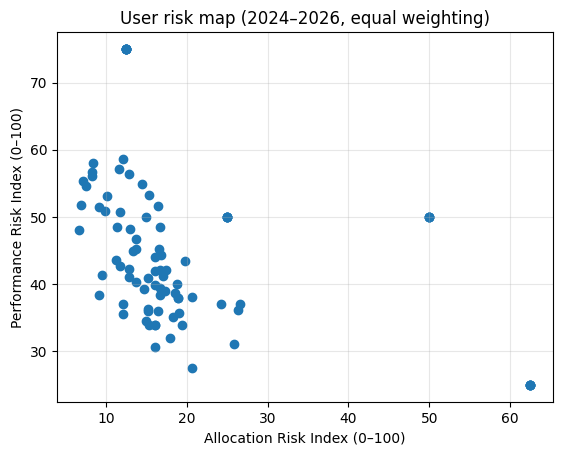

,username,n_picks,ARI,PRI,user_type
4,DKWoods,2,62.500000,25.000000,chalk_burner
5,GopherHockey19,2,62.500000,25.000000,chalk_burner
6,Tbargie,2,62.500000,25.000000,chalk_burner
7,ThePME,2,62.500000,25.000000,chalk_burner
8,bpark88,2,62.500000,25.000000,chalk_burner
0,Jwhit25,2,50.000000,50.000000,chaos
2,SJUPRIDE10,2,50.000000,50.000000,chaos
3,Zsather,2,50.000000,50.000000,chaos
1,Ottomatic,2,50.000000,50.000000,chaos
21,nausetsurf,31,26.612903,37.096774,gambler


,username,n_picks,ARI,PRI,user_type,sig_longshot_rate
12,GH23,2,12.500000,75.000000,gambler,0.000000
13,Kriegs,2,12.500000,75.000000,gambler,0.000000
15,andylicious,2,12.500000,75.000000,gambler,0.000000
14,Rye1987,2,12.500000,75.000000,gambler,0.000000
9,ADmun,2,12.500000,75.000000,gambler,0.000000
10,Cjlemoin,2,12.500000,75.000000,gambler,0.000000
11,FlyingArmbar,2,12.500000,75.000000,gambler,0.000000
22,one007,64,12.109375,58.593750,gambler,0.078125
33,halliam1114,62,8.467742,58.064516,gambler,0.032258
28,NinnaNation,28,11.607143,57.142857,gambler,0.071429


In [34]:
# =========================
# Cell 9 — Plot: ARI vs PRI (where users “hover”)
# =========================
plt.figure()
plt.scatter(profiles["ARI"], profiles["PRI"])
plt.xlabel("Allocation Risk Index (0–100)")
plt.ylabel("Performance Risk Index (0–100)")
plt.title("User risk map (2024–2026, equal weighting)")
plt.grid(True, alpha=0.3)
plt.show()

# Optional: show the extremes (helps validate)
display(profiles.sort_values("ARI", ascending=False).head(15)[["username","n_picks","ARI","PRI","user_type"]])
display(profiles.sort_values("PRI", ascending=False).head(15)[["username","n_picks","ARI","PRI","user_type","sig_longshot_rate"]])


In [35]:
# =========================
# Cell 10 — Save outputs (optional)
# =========================
OUT_PROFILES = CLEAN_LEAGUES / "user_risk_profiles_2024_2026.csv"
OUT_PICKLEVEL = CLEAN_LEAGUES / "picks_with_risk_components_2024_2026.csv"

profiles.to_csv(OUT_PROFILES, index=False)
picks3.to_csv(OUT_PICKLEVEL, index=False)

print("Wrote:", OUT_PROFILES)
print("Wrote:", OUT_PICKLEVEL)


Wrote: /Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues/user_risk_profiles_2024_2026.csv
Wrote: /Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues/picks_with_risk_components_2024_2026.csv


In [36]:
### TEST

In [70]:
# =========================
# Cell 1 — Paths + config (week_num from start_date)
# =========================
from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata
from difflib import SequenceMatcher

DATA_IN_USE = Path("/Users/joshmacbook/python_projects/OAD/Data/in Use")
CLEAN_LEAGUES = Path("/Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues")

PICKS_PATHS = [
    CLEAN_LEAGUES / "2024_small_normalized.csv",
    CLEAN_LEAGUES / "2025_small_normalized.csv",
    CLEAN_LEAGUES / "2026_small_normalized.csv",
]

SCHEDULE_PATHS = {
    2024: DATA_IN_USE / "OAD_2024.xlsx",
    2025: DATA_IN_USE / "OAD_2025.xlsx",
    2026: DATA_IN_USE / "OAD_2026.xlsx",
}

ODDS_XLSX_PATH = DATA_IN_USE / "Odds_and_Results.xlsx"

SEASONS = [2024, 2025, 2026]
EARLY_CUTOFF_WEEK = 16  # weeks 1–16 early, 17–31 late

# Odds bands
ELITE_CUTOFF = 20.0
LONGSHOT_CUTOFF = 50.0

print("OK")


OK


In [71]:
# =========================
# Cell 2 — Load picks (2024–2026 normalized) and standardize dtypes
# =========================
picks = pd.concat([pd.read_csv(p) for p in PICKS_PATHS], ignore_index=True)

need = {
    "season","event_id","event_name","event_date",
    "entry_id","username","player_name","dg_id","raw_winnings"
}
missing = need - set(picks.columns)
if missing:
    raise ValueError(f"Missing columns in picks: {sorted(missing)}")

picks["season"] = pd.to_numeric(picks["season"], errors="coerce").astype("Int64")
picks["event_id"] = pd.to_numeric(picks["event_id"], errors="coerce").astype("Int64")
picks["dg_id"] = pd.to_numeric(picks["dg_id"], errors="coerce").astype("Int64")
picks["event_date"] = pd.to_datetime(picks["event_date"], errors="coerce")
picks = picks[picks["season"].isin(SEASONS)].copy()

print("Picks rows:", len(picks))
display(picks.head(5))


Picks rows: 3052


,season,league_id,event_name,event_date,event_key,event_id,entry_id,username,player_name,dg_id,raw_winnings
0,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,jjhzg65,9thGreenAtNine,Si Woo Kim,14609,25913.0
1,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,64h9j7o,AKsREVENGE,Chris Kirk,12423,106102.0
2,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,43hrmz5,anpyanks,Corey Conners,17576,18592.0
3,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,dnhqm0e,balvari,Ludvig Aberg,23950,44751.0
4,2024,2024_small,Sony Open in Hawaii,2024-01-11,Sony Open in Hawaii_2024-01-11,6,qzhkx78,BigCat97,Russell Henley,14578,373500.0


In [72]:
# =========================
# Cell 3 — Load schedules and build week_num = 1..N per season using start_date
# =========================
def load_schedule_with_weeknum(season: int, path: Path) -> pd.DataFrame:
    s = pd.read_excel(path)
    s.columns = [str(c).lower() for c in s.columns]

    if "event_id" not in s.columns:
        raise ValueError(f"Schedule {season} missing event_id. Cols: {s.columns.tolist()}")
    if "start_date" not in s.columns:
        raise ValueError(f"Schedule {season} missing start_date. Cols: {s.columns.tolist()}")

    s["event_id"] = pd.to_numeric(s["event_id"], errors="coerce").astype("Int64")
    s["start_date"] = pd.to_datetime(s["start_date"], errors="coerce")

    # Keep only valid events with start_date and event_id
    s = s.dropna(subset=["event_id","start_date"]).copy()

    s = s.sort_values("start_date").reset_index(drop=True)
    s["week_num"] = np.arange(1, len(s) + 1, dtype=int)
    s["phase"] = np.where(s["week_num"] <= EARLY_CUTOFF_WEEK, "early", "late")
    s["season"] = season

    # Optional: keep event_name if present
    if "event_name" not in s.columns:
        # try common alternatives
        for alt in ["event", "tournament", "tournament_name"]:
            if alt in s.columns:
                s["event_name"] = s[alt].astype(str)
                break
        if "event_name" not in s.columns:
            s["event_name"] = ""

    return s[["season","event_id","start_date","week_num","phase","event_name"]]

sched = pd.concat(
    [load_schedule_with_weeknum(season, path) for season, path in SCHEDULE_PATHS.items()],
    ignore_index=True
)

print("Schedule rows:", len(sched))
display(sched.head(10))


Schedule rows: 92


,season,event_id,start_date,week_num,phase,event_name
0,2024,6,2024-01-14,1,early,Sony Open in Hawaii
1,2024,2,2024-01-21,2,early,The American Express
2,2024,4,2024-01-27,3,early,Farmers Insurance Open
3,2024,5,2024-02-04,4,early,AT&T Pebble Beach Pro-Am
4,2024,3,2024-02-11,5,early,WM Phoenix Open
5,2024,7,2024-02-18,6,early,The Genesis Invitational
6,2024,540,2024-02-25,7,early,Mexico Open at Vidanta
7,2024,10,2024-03-03,8,early,Cognizant Classic in The Palm Beaches
8,2024,9,2024-03-10,9,early,Arnold Palmer Invitational presented by Master...
9,2024,11,2024-03-17,10,early,THE PLAYERS Championship


In [73]:
# =========================
# Cell 4 — Merge week_num + phase onto picks by (season, event_id)
# =========================
picks_w = picks.merge(
    sched[["season","event_id","week_num","phase","start_date"]],
    on=["season","event_id"],
    how="left"
)

# sanity checks
missing_week = picks_w["week_num"].isna().sum()
print("Missing week_num:", missing_week)

# if any missing, show examples so you can see which event_ids didn't match schedule
if missing_week:
    display(
        picks_w[picks_w["week_num"].isna()][["season","event_id","event_name","event_date","username","player_name"]]
        .drop_duplicates()
        .head(25)
    )

display(
    picks_w[["season","event_id","event_name","start_date","week_num","phase"]]
    .drop_duplicates()
    .sort_values(["season","week_num"])
    .head(20)
)


Missing week_num: 0


,season,event_id,event_name,start_date,week_num,phase
0,2024,6,Sony Open in Hawaii,2024-01-14,1,early
49,2024,2,The American Express,2024-01-21,2,early
98,2024,4,Farmers Insurance Open,2024-01-27,3,early
145,2024,5,AT&T Pebble Beach Pro-Am,2024-02-04,4,early
194,2024,3,WM Phoenix Open,2024-02-11,5,early
242,2024,7,The Genesis Invitational,2024-02-18,6,early
291,2024,540,Mexico Open at Vidanta,2024-02-25,7,early
340,2024,10,Cognizant Classic in The Palm Beaches,2024-03-03,8,early
388,2024,9,Arnold Palmer Invitational presented by Master...,2024-03-10,9,early
436,2024,11,THE PLAYERS Championship,2024-03-17,10,early


In [74]:
# =========================
# Cell 5 — Odds helpers: banding
# =========================
def pick_band(close_odds: float) -> str:
    # missing -> normie (your rule)
    if close_odds is None or (isinstance(close_odds, float) and np.isnan(close_odds)):
        return "normie"
    if close_odds < ELITE_CUTOFF:
        return "elite"
    if close_odds >= LONGSHOT_CUTOFF:
        return "longshot"
    return "normie"


In [75]:
# =========================
# Cell 6 — Load Odds_and_Results (find correct sheet automatically)
#   Need: year/season, event_id, dg_id, close_odds, event_tier
# =========================
xl = pd.ExcelFile(ODDS_XLSX_PATH)

required = {"event_id", "dg_id", "close_odds", "event_tier"}
year_candidates = ["year", "season"]

odds = None
odds_sheet = None
year_col = None

for sh in xl.sheet_names:
    t = xl.parse(sh)
    cols = {str(c).lower() for c in t.columns}
    if required.issubset(cols) and any(y in cols for y in year_candidates):
        odds = t
        odds_sheet = sh
        year_col = "year" if "year" in cols else "season"
        break

if odds is None:
    raise ValueError(
        "Could not find a sheet in Odds_and_Results.xlsx containing "
        "event_id, dg_id, close_odds, event_tier, and year/season"
    )

odds.columns = [str(c).lower() for c in odds.columns]

odds[year_col] = pd.to_numeric(odds[year_col], errors="coerce").astype("Int64")
odds["event_id"] = pd.to_numeric(odds["event_id"], errors="coerce").astype("Int64")
odds["dg_id"] = pd.to_numeric(odds["dg_id"], errors="coerce").astype("Int64")
odds["close_odds"] = pd.to_numeric(odds["close_odds"], errors="coerce")
odds["event_tier"] = odds["event_tier"].astype(str).str.lower().str.strip()

# keep relevant seasons + clean rows
odds = odds[odds[year_col].isin(SEASONS)].copy()

# one row per (season,event_id,dg_id): take last
odds1 = (
    odds.sort_values([year_col, "event_id", "dg_id"])
        .drop_duplicates([year_col, "event_id", "dg_id"], keep="last")
        [[year_col, "event_id", "dg_id", "close_odds", "event_tier"]]
        .copy()
)

print("Using odds sheet:", odds_sheet)
print("Odds rows:", len(odds1))
display(odds1.head(5))


Using odds sheet: Sheet1
Odds rows: 8222


,year,event_id,dg_id,close_odds,event_tier
4489,2024,2,5768,301.0,regular
4457,2024,2,6169,111.0,regular
4498,2024,2,6252,401.0,regular
4408,2024,2,6986,501.0,regular
4518,2024,2,7301,1001.0,regular


In [76]:
# =========================
# Cell 7 — Merge odds onto picks (close_odds + event_tier) and compute pick_band
# =========================
odds1_ren = odds1.rename(columns={year_col: "season"}).copy()

picks_o = picks_w.merge(
    odds1_ren,
    on=["season", "event_id", "dg_id"],
    how="left"
)

# if any close_odds missing for actual pick, treat as normie (your rule)
picks_o["pick_band"] = picks_o["close_odds"].apply(pick_band)

# event_tier should exist; if missing, default to 'regular' so model still runs
picks_o["event_tier"] = picks_o["event_tier"].fillna("regular").astype(str).str.lower().str.strip()

print("Picks rows:", len(picks_o))
print("Missing close_odds on actual picks:", picks_o["close_odds"].isna().sum())
display(picks_o[["season","week_num","event_id","event_tier","username","player_name","dg_id","close_odds","pick_band"]].head(12))


Picks rows: 3052
Missing close_odds on actual picks: 76


,season,week_num,event_id,event_tier,username,player_name,dg_id,close_odds,pick_band
0,2024,1,6,regular,9thGreenAtNine,Si Woo Kim,14609,36.0,normie
1,2024,1,6,regular,AKsREVENGE,Chris Kirk,12423,23.0,normie
2,2024,1,6,regular,anpyanks,Corey Conners,17576,29.0,normie
3,2024,1,6,regular,balvari,Ludvig Aberg,23950,21.0,normie
4,2024,1,6,regular,BigCat97,Russell Henley,14578,21.0,normie
5,2024,1,6,regular,Bjrobins123,Chris Kirk,12423,23.0,normie
6,2024,1,6,regular,CashMonet,Corey Conners,17576,29.0,normie
7,2024,1,6,regular,chrismurf21,J.T. Poston,21554,31.0,normie
8,2024,1,6,regular,docpalm,Adam Svensson,13997,41.0,normie
9,2024,1,6,regular,Donkosaurus,Corey Conners,17576,29.0,normie


In [77]:
# =========================
# Cell 8 — Build field candidates for each (season,event_id)
#   This is the set of golfers we can choose from when predicting picks.
# =========================
field = odds1_ren.merge(
    sched[["season","event_id","week_num","phase","start_date"]],
    on=["season","event_id"],
    how="left"
)

field["pick_band"] = field["close_odds"].apply(pick_band)
field = field.dropna(subset=["season","event_id","dg_id"]).copy()

# sanity
print("Field rows:", len(field))
print("Distinct events in field:", field[["season","event_id"]].drop_duplicates().shape[0])
display(field.head(10))


Field rows: 8222
Distinct events in field: 67


,season,event_id,dg_id,close_odds,event_tier,week_num,phase,start_date,pick_band
0,2024,2,5768,301.0,regular,2.0,early,2024-01-21,longshot
1,2024,2,6169,111.0,regular,2.0,early,2024-01-21,longshot
2,2024,2,6252,401.0,regular,2.0,early,2024-01-21,longshot
3,2024,2,6986,501.0,regular,2.0,early,2024-01-21,longshot
4,2024,2,7301,1001.0,regular,2.0,early,2024-01-21,longshot
5,2024,2,7305,1001.0,regular,2.0,early,2024-01-21,longshot
6,2024,2,7489,251.0,regular,2.0,early,2024-01-21,longshot
7,2024,2,7820,251.0,regular,2.0,early,2024-01-21,longshot
8,2024,2,7900,801.0,regular,2.0,early,2024-01-21,longshot
9,2024,2,7959,2501.0,regular,2.0,early,2024-01-21,longshot


In [78]:
# =========================
# Cell 8.5 — Precompute pct_in_band for field, and pick_pct_in_band for picks
# =========================

def add_pct_in_band(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each (season,event_id,pick_band), assign pct_in_band:
      0.0 = shortest odds in band, 1.0 = longest odds in band
    """
    df = df.copy()
    df["pct_in_band"] = np.nan

    keys = ["season", "event_id", "pick_band"]
    for (s, e, b), sub in df.groupby(keys):
        sub = sub.sort_values("close_odds", ascending=True)
        n = len(sub)
        if n == 1:
            df.loc[sub.index, "pct_in_band"] = 0.0
        else:
            df.loc[sub.index, "pct_in_band"] = np.linspace(0.0, 1.0, n)

    return df

# Add pct_in_band to the full event field table
field2 = add_pct_in_band(field)

# Attach pick_pct_in_band to each actual pick (where close_odds exists)
picks_o2 = picks_o.merge(
    field2[["season","event_id","dg_id","pct_in_band"]],
    on=["season","event_id","dg_id"],
    how="left"
)

print("field2 pct_in_band missing:", field2["pct_in_band"].isna().sum())
print("picks_o2 pick_pct_in_band missing:", picks_o2["pct_in_band"].isna().sum())
display(picks_o2[["season","week_num","event_id","username","dg_id","close_odds","pick_band","pct_in_band"]].head(10))

field2 pct_in_band missing: 0
picks_o2 pick_pct_in_band missing: 76


,season,week_num,event_id,username,dg_id,close_odds,pick_band,pct_in_band
0,2024,1,6,9thGreenAtNine,14609,36.0,normie,0.6875
1,2024,1,6,AKsREVENGE,12423,23.0,normie,0.1250
2,2024,1,6,anpyanks,17576,29.0,normie,0.2500
3,2024,1,6,balvari,23950,21.0,normie,0.0000
4,2024,1,6,BigCat97,14578,21.0,normie,0.0625
5,2024,1,6,Bjrobins123,12423,23.0,normie,0.1250
6,2024,1,6,CashMonet,17576,29.0,normie,0.2500
7,2024,1,6,chrismurf21,21554,31.0,normie,0.3750
8,2024,1,6,docpalm,13997,41.0,normie,0.8125
9,2024,1,6,Donkosaurus,17576,29.0,normie,0.2500


In [79]:
# =========================
# Cell 9 — Training rule: build per-user history available before a given (season,week_num)
#   - 'used' is season-local
#   - For 2025 predictions:
#       * if user has 2024 history -> include all 2024 + 2025 prior weeks
#       * else -> include 2025 weeks 1–2 (bootstrap) + 2025 prior weeks
# =========================
BANDS = ["elite", "normie", "longshot"]

def get_user_history_for_2025(user: str, week_k: int, picks_df: pd.DataFrame) -> pd.DataFrame:
    """Return training history for predicting 2025 week_k for this user."""
    u_all = picks_df[picks_df["username"] == user].copy()

    has_2024 = (u_all["season"] == 2024).any()

    # always include 2025 prior weeks
    hist_2025 = u_all[(u_all["season"] == 2025) & (u_all["week_num"] < week_k)].copy()

    if has_2024:
        hist_2024 = u_all[u_all["season"] == 2024].copy()
        hist = pd.concat([hist_2024, hist_2025], ignore_index=True)
    else:
        # bootstrap: weeks 1–2 of 2025 (even if predicting week 3+)
        boot = u_all[(u_all["season"] == 2025) & (u_all["week_num"].isin([1,2]))].copy()
        hist = pd.concat([boot, hist_2025], ignore_index=True).drop_duplicates(
            subset=["season","event_id","dg_id"]
        )

    return hist

def user_used_in_season(user: str, season: int, week_k: int, picks_df: pd.DataFrame) -> set:
    """Players used by user in same season in weeks < week_k."""
    u = picks_df[(picks_df["username"] == user) & (picks_df["season"] == season) & (picks_df["week_num"] < week_k)]
    return set(u["dg_id"].dropna().astype(int).tolist())


In [127]:
# =========================
# Cell 10 — Predict exact pick (Target 2) for 2025 weeks 3+ (walk-forward by week_num)
#   Output:
#     - predicted band probs (Dirichlet-smoothed counts by context)
#     - Top-1 and Top-3 dg_ids from event field excluding used
#     - confidence: top1_prob, top3_prob
# =========================
BETA = 1.0  # >1 more chalk, <1 more spread; tweak week-by-week
ALPHA = 1.0        # smoothing in Dirichlet
SIGMA_PCT = 0.18   # how tight a user sticks to their typical band-rank (smaller = more consistent)
USE_CONTEXT_FOR_MU = True  # if True: learn mu_pct from same (event_tier, phase) when possible

def band_probs_blended(hist: pd.DataFrame, event_tier: str, phase: str,
                       alpha: float = 1.0) -> tuple[dict, int]:
    """
    Returns (probs, n_ctx) where probs is blended:
      probs = w * probs_context + (1-w) * probs_user_global
    w increases with context sample size, so we only lean on context when we have data.

    Backoff inside context: (tier+phase) -> tier-only -> global
    """
    def posterior_mean(df):
        counts = df["pick_band"].value_counts().reindex(BANDS).fillna(0.0).astype(float)
        counts = counts + alpha
        return (counts / counts.sum()).to_dict()

    # User-global tendency (always defined if hist non-empty)
    if len(hist) >= 1:
        p_user = posterior_mean(hist)
    else:
        # no history at all: priors
        if event_tier == "signature":
            p_user = {"elite": 0.70, "normie": 0.25, "longshot": 0.05}
        elif phase == "early":
            p_user = {"elite": 0.10, "normie": 0.75, "longshot": 0.15}
        else:
            p_user = {"elite": 0.50, "normie": 0.40, "longshot": 0.10}

    # Context candidates
    ctx = hist[(hist["event_tier"] == event_tier) & (hist["phase"] == phase)]
    if len(ctx) >= 1:
        p_ctx = posterior_mean(ctx)
        n_ctx = len(ctx)
    else:
        tier = hist[(hist["event_tier"] == event_tier)]
        if len(tier) >= 1:
            p_ctx = posterior_mean(tier)
            n_ctx = len(tier)
        else:
            p_ctx = p_user
            n_ctx = 0

    # Blend weight: ramps from ~0.25 at 1 obs to ~0.8 by ~10 obs
    # (tune later week-by-week)
# stronger reliance on user-global in early 2026 weeks (cold start)
    # -------------------------
    # Blend weight (SAFE; avoids pd.NA boolean issues)
    # -------------------------
    max_season = None
    if "season" in hist.columns:
        mx = pd.to_numeric(hist["season"], errors="coerce").max()
        if pd.notna(mx):
            max_season = int(mx)

    # stronger reliance on user-global before we've observed any 2026 behavior
    if max_season == 2026:
        w = n_ctx / (n_ctx + 3.0) if n_ctx > 0 else 0.0
    else:
        w = n_ctx / (n_ctx + 8.0) if n_ctx > 0 else 0.0

    probs = {b: w * p_ctx.get(b, 0) + (1 - w) * p_user.get(b, 0) for b in BANDS}

    # normalize
    s = sum(probs.values())
    if s > 0:
        probs = {k: v / s for k, v in probs.items()}

    return probs, n_ctx

def within_band_weight(close_odds: float, beta: float = 1.0) -> float:
    if close_odds is None or (isinstance(close_odds, float) and np.isnan(close_odds)) or close_odds <= 0:
        return 0.0
    return (1.0 / close_odds) ** beta

def _percentile_rank_within_band(f: pd.DataFrame) -> pd.Series:
    """
    Compute percentile rank within pick_band for the current event field.
    0.0 = shortest odds in the band, 1.0 = longest odds in the band
    """
    out = pd.Series(index=f.index, dtype=float)
    for band in BANDS:
        idx = f.index[f["pick_band"] == band]
        if len(idx) == 0:
            continue
        sub = f.loc[idx].sort_values("close_odds", ascending=True)
        # percentile positions
        if len(sub) == 1:
            out.loc[sub.index] = 0.0
        else:
            out.loc[sub.index] = np.linspace(0.0, 1.0, len(sub))
    return out

def _user_mu_pct(hist: pd.DataFrame, event_tier: str, phase: str) -> float:
    """
    User's typical "where in the band" they pick, as a percentile (0=very chalk within band).
    Uses hist rows that already have odds + pick_band.
    """
    h = hist.dropna(subset=["close_odds","pick_band"]).copy()
    if h.empty:
        return 0.20  # default: somewhat chalky within band

    if USE_CONTEXT_FOR_MU:
        h_ctx = h[(h["event_tier"] == event_tier) & (h["phase"] == phase)]
        if len(h_ctx) >= 3:
            h = h_ctx

    # Convert each historical pick to a percentile within ITS band for THAT event:
    # We approximate this by percentile within that band across the event field using close_odds distribution in hist.
    # (Good enough to start; we can make it exact with per-event field lookup later.)
    mu = h.groupby("pick_band")["close_odds"].median()

    # Map bands to a scalar mu via weighted average of band medians (fallback if missing)
    # Then convert to a generic percentile target:
    # lower median odds => more chalky => lower percentile
    med = h["close_odds"].median()
    if pd.isna(med):
        return 0.20

    # crude mapping: use rank of median odds within user's own history
    ranks = h["close_odds"].rank(pct=True)
    return float(ranks.median())

def predict_user_event_2025(user: str, event_row: pd.Series, picks_df: pd.DataFrame, field_df: pd.DataFrame) -> dict:
    season = int(event_row["season"])
    week_k = int(event_row["week_num"])
    event_id = int(event_row["event_id"])
    event_tier = str(event_row["event_tier"]).lower().strip()
    phase = str(event_row["phase"])

    # training history per your rule
    hist = get_user_history_for_2025(user, week_k, picks_df)

    # used players season-local
    used = user_used_in_season(user, season, week_k, picks_df)

    # candidate field for this event
    f = field_df[(field_df["season"] == season) & (field_df["event_id"] == event_id)].copy()
    f = f.dropna(subset=["dg_id","close_odds"]).copy()
    f["dg_id"] = f["dg_id"].astype(int)
    f = f[~f["dg_id"].isin(used)].copy()

    if f.empty:
        return {"pred_top1": None, "pred_top3": [], "top1_prob": np.nan, "top3_prob": np.nan, "band_probs": {}}

    # --- band probabilities with smoothing/backoff ---
    probs, n_ctx = band_probs_blended(hist, event_tier, phase, alpha=ALPHA)

    # --- score candidates using user-specific mu by band (learned from history) ---
    f["band_prob"] = f["pick_band"].map(probs).fillna(probs.get("normie", 1/3))

    # mu_pct by band from historical picks (use the precomputed pick pct_in_band)
    h = hist.dropna(subset=["pct_in_band"]).copy()

    # optionally: context-only mu if enough samples, else fallback to global mu
    h_ctx = h[(h["event_tier"] == event_tier) & (h["phase"] == phase)]
    use_h = h_ctx if len(h_ctx) >= 5 else h

    mu_by_band = use_h.groupby("pick_band")["pct_in_band"].median().to_dict()

    # defaults: most people are fairly chalky within their band
    DEFAULT_MU = {"elite": 0.15, "normie": 0.25, "longshot": 0.35}

    f["mu"] = f["pick_band"].map(mu_by_band)
    f["mu"] = f["mu"].fillna(f["pick_band"].map(DEFAULT_MU))

    # Gaussian preference around mu within each band
    f["within_w"] = np.exp(-((f["pct_in_band"] - f["mu"]) ** 2) / (2 * (SIGMA_PCT ** 2)))

    f["score"] = f["band_prob"] * f["within_w"]

    # convert to probabilities
    total = f["score"].sum()
    if total <= 0:
        # fallback to pure chalk
        f = f.sort_values("close_odds", ascending=True)
        top3 = f.head(3)["dg_id"].astype(int).tolist()
        top1 = top3[0] if top3 else None
        return {"pred_top1": top1, "pred_top3": top3, "top1_prob": np.nan, "top3_prob": np.nan, "band_probs": probs}

    f["p"] = f["score"] / total
    f = f.sort_values("p", ascending=False)

    top1 = int(f.iloc[0]["dg_id"])
    top3 = f.head(3)["dg_id"].astype(int).tolist()
    top1_prob = float(f.iloc[0]["p"])
    top3_prob = float(f.head(3)["p"].sum())

    return {"pred_top1": top1, "pred_top3": top3, "top1_prob": top1_prob, "top3_prob": top3_prob, "band_probs": probs}

In [105]:
# =========================
# Cell 11 — Week-by-week backtest starting at 2025 week 3
#   Produces per-week metrics + a detailed predictions table you can inspect/tweak.
# =========================

# Actual picks for 2025 (join in event_tier from field if needed)
actual_2025 = picks_o[picks_o["season"] == 2025].copy()
actual_2025 = actual_2025.dropna(subset=["week_num","event_id","username","dg_id"]).copy()
actual_2025["week_num"] = actual_2025["week_num"].astype(int)
actual_2025["dg_id"] = actual_2025["dg_id"].astype(int)
actual_2025["event_tier"] = actual_2025["event_tier"].astype(str).str.lower().str.strip()

# Event list (one row per event/week)
events_2025 = (
    actual_2025[["season","week_num","event_id","event_tier","phase"]]
    .drop_duplicates()
    .sort_values("week_num")
)

# Storage
pred_rows = []

for _, ev in events_2025.iterrows():
    week_k = int(ev["week_num"])
    if week_k < 3:
        continue  # start at week 3

    season = 2025
    event_id = int(ev["event_id"])
    event_tier = str(ev["event_tier"]).lower().strip()
    phase = str(ev["phase"])

    # all actual picks for this event/week
    week_picks = actual_2025[(actual_2025["week_num"] == week_k) & (actual_2025["event_id"] == event_id)].copy()
    if week_picks.empty:
        continue

    for _, a in week_picks.iterrows():
        user = a["username"]
        actual_dg = int(a["dg_id"])
        actual_band = a["pick_band"]

        pred = predict_user_event_2025(
            user=user,
            event_row=ev,
            picks_df=picks_o2,  # now includes pct_in_band
            field_df=field2     # now includes pct_in_band
        )

        pred_rows.append({
            "season": 2025,
            "week_num": week_k,
            "event_id": event_id,
            "event_tier": event_tier,
            "phase": phase,
            "username": user,

            "actual_dg_id": actual_dg,
            "actual_band": actual_band,

            "pred_top1": pred["pred_top1"],
            "pred_top3": pred["pred_top3"],
            "top1_prob": pred["top1_prob"],
            "top3_prob": pred["top3_prob"],

            "hit_top1": int(pred["pred_top1"] == actual_dg),
            "hit_top3": int(actual_dg in set(pred["pred_top3"])) if pred["pred_top3"] else 0,

            # band probs for debugging
            "p_elite": pred["band_probs"].get("elite", np.nan),
            "p_normie": pred["band_probs"].get("normie", np.nan),
            "p_longshot": pred["band_probs"].get("longshot", np.nan),
        })

bt_week = pd.DataFrame(pred_rows)

print("Backtest rows:", len(bt_week))
display(bt_week.head(10))


Backtest rows: 1627


,season,week_num,event_id,event_tier,phase,username,actual_dg_id,actual_band,pred_top1,pred_top3,top1_prob,top3_prob,hit_top1,hit_top3,p_elite,p_normie,p_longshot
0,2025,3,4,regular,early,9thGreenAtNine,18634,normie,17780,"[17780, 18634, 17538]",0.081495,0.230881,0,1,0.191111,0.735556,0.073333
1,2025,3,4,regular,early,AKsREVENGE,9771,normie,17780,"[17780, 18634, 17538]",0.064533,0.182372,0,0,0.497778,0.400000,0.102222
2,2025,3,4,regular,early,AndinoSmiles,13562,elite,23950,"[23950, 11676, 23465]",0.029135,0.081765,0,0,0.400000,0.400000,0.200000
3,2025,3,4,regular,early,BigBoKnows,17780,normie,17536,"[17536, 18554, 16394]",0.026442,0.079279,0,0,0.200000,0.400000,0.400000
4,2025,3,4,regular,early,BigCat97,23950,elite,18634,"[18634, 17780, 17538]",0.071992,0.203959,0,0,0.289412,0.623529,0.087059
5,2025,3,4,regular,early,Caleb2023,9771,normie,14609,"[14609, 13900, 15470]",0.027939,0.078994,0,0,0.400000,0.400000,0.200000
6,2025,3,4,regular,early,Cdimming,9771,normie,17488,"[17488, 28635, 12808]",0.029163,0.059000,0,0,0.600000,0.200000,0.200000
7,2025,3,4,regular,early,Dreamweaver816,23465,normie,23014,"[23014, 17538, 23465]",0.101816,0.288416,0,1,0.211429,0.737143,0.051429
8,2025,3,4,regular,early,Enicola0922,23014,normie,23014,"[23014, 23465, 17538]",0.091732,0.259307,1,1,0.231111,0.666667,0.102222
9,2025,3,4,regular,early,GlizzyAtTheTurn,9771,normie,11676,"[11676, 13872, 9771]",0.072901,0.206417,0,1,0.402222,0.473333,0.124444


In [106]:
# =========================
# Cell 12 — Week-by-week metrics (so you can tweak model week to week)
# =========================
def summarize(df):
    return pd.Series({
        "n_users": df["username"].nunique(),
        "n_picks": len(df),
        "top1_acc": df["hit_top1"].mean(),
        "top3_hit": df["hit_top3"].mean(),
        "avg_top1_prob": df["top1_prob"].mean(),
        "avg_top3_prob": df["top3_prob"].mean(),
    })

wk_metrics = (
    bt_week.groupby(["week_num","event_id","event_tier","phase"])
           .apply(summarize)
           .reset_index()
           .sort_values("week_num")
)

display(wk_metrics)


/var/folders/85/gv9dnstn1tn96gql2f7mj15h0000gn/T/ipykernel_42583/3686539233.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize)


,week_num,event_id,event_tier,phase,n_users,n_picks,top1_acc,top3_hit,avg_top1_prob,avg_top3_prob
0,3,4,regular,early,48.0,48.0,0.166667,0.333333,0.056025,0.155178
1,4,5,signature,early,49.0,49.0,0.040816,0.122449,0.089122,0.215519
2,5,3,regular,early,49.0,49.0,0.102041,0.326531,0.080011,0.178323
3,6,7,signature,early,49.0,49.0,0.081633,0.163265,0.082703,0.227328
4,8,10,regular,early,49.0,49.0,0.000000,0.020408,0.060027,0.170815
5,9,9,signature,early,49.0,49.0,0.102041,0.306122,0.104425,0.256941
6,10,11,signature,early,49.0,49.0,0.081633,0.224490,0.060778,0.137028
7,11,475,regular,early,46.0,46.0,0.086957,0.152174,0.070885,0.189082
8,12,20,regular,early,49.0,49.0,0.102041,0.285714,0.072071,0.197136
9,13,41,regular,early,49.0,49.0,0.142857,0.306122,0.073921,0.207458


In [107]:
# =========================
# Week-by-week: add band accuracy + pred_band counts
# =========================
def add_pred_band(df):
    df = df.copy()
    def argmax_band(r):
        d = {"elite": r["p_elite"], "normie": r["p_normie"], "longshot": r["p_longshot"]}
        d = {k: (v if pd.notna(v) else -1.0) for k, v in d.items()}
        return max(d.items(), key=lambda kv: kv[1])[0]
    df["pred_band"] = df.apply(argmax_band, axis=1)
    df["hit_band"] = (df["pred_band"] == df["actual_band"]).astype(int)
    return df

bt_week2 = add_pred_band(bt_week)

wk_metrics2 = (
    bt_week2.groupby(["week_num","event_id","event_tier","phase"])
    .agg(
        n_picks=("actual_dg_id","size"),
        top1_acc=("hit_top1","mean"),
        top3_hit=("hit_top3","mean"),
        band_acc=("hit_band","mean"),
        avg_top1_prob=("top1_prob","mean"),
        avg_top3_prob=("top3_prob","mean"),
        uniq_pred_top1=("pred_top1","nunique"),
    )
    .reset_index()
    .sort_values("week_num")
)

display(wk_metrics2)


,week_num,event_id,event_tier,phase,n_picks,top1_acc,top3_hit,band_acc,avg_top1_prob,avg_top3_prob,uniq_pred_top1
0,3,4,regular,early,48,0.166667,0.333333,0.625000,0.056025,0.155178,13
1,4,5,signature,early,49,0.040816,0.122449,0.306122,0.089122,0.215519,11
2,5,3,regular,early,49,0.102041,0.326531,0.387755,0.080011,0.178323,6
3,6,7,signature,early,49,0.081633,0.163265,0.428571,0.082703,0.227328,15
4,8,10,regular,early,49,0.000000,0.020408,0.795918,0.060027,0.170815,12
5,9,9,signature,early,49,0.102041,0.306122,0.489796,0.104425,0.256941,12
6,10,11,signature,early,49,0.081633,0.224490,0.408163,0.060778,0.137028,9
7,11,475,regular,early,46,0.086957,0.152174,0.456522,0.070885,0.189082,8
8,12,20,regular,early,49,0.102041,0.285714,0.734694,0.072071,0.197136,8
9,13,41,regular,early,49,0.142857,0.306122,0.612245,0.073921,0.207458,10


In [108]:
def show_week_full(week_k: int, n=50):
    d = bt_week2[bt_week2["week_num"] == week_k].copy()
    d["pred_top3_str"] = d["pred_top3"].apply(lambda x: ", ".join(map(str, x)) if isinstance(x, list) else "")
    d = d.sort_values(["hit_top3","top3_prob","top1_prob"], ascending=[False, False, False])
    cols = [
        "week_num","event_id","event_tier","phase","username",
        "actual_band","pred_band","hit_band",
        "actual_dg_id","pred_top1","hit_top1","pred_top3_str","hit_top3",
        "top1_prob","top3_prob",
        "p_elite","p_normie","p_longshot"
    ]
    return d[cols].head(n)

display(show_week_full(4, n=100))


,week_num,event_id,event_tier,phase,username,actual_band,pred_band,hit_band,actual_dg_id,pred_top1,hit_top1,pred_top3_str,hit_top3,top1_prob,top3_prob,p_elite,p_normie,p_longshot
63,4,5,signature,early,jonescurtisw,elite,elite,1,15466,22085,0,"22085, 15466, 12294",1,0.134379,0.336099,0.523129,0.412162,0.064709
62,4,5,signature,early,joempike,elite,normie,0,15466,13562,0,"13562, 22085, 15466",1,0.105494,0.281223,0.408524,0.510135,0.081341
95,4,5,signature,early,Walshy0104,elite,elite,1,15466,15466,1,"15466, 17488, 22085",1,0.107742,0.270079,0.489865,0.412162,0.097973
60,4,5,signature,early,JermRussLFG,elite,elite,1,14139,14139,1,"14139, 22085, 9771",1,0.071372,0.206447,0.486538,0.377473,0.135989
84,4,5,signature,early,Pjh5165,normie,normie,1,13562,17488,0,"17488, 13562, 23950",1,0.079105,0.187014,0.333333,0.500000,0.166667
72,4,5,signature,early,MasterJ12thMan,normie,elite,0,9771,18417,0,"18417, 9771, 17488",1,0.054974,0.149839,0.400000,0.400000,0.200000
55,4,5,signature,early,Dreamweaver816,elite,normie,0,23950,12294,0,"12294, 19483, 9771",0,0.165726,0.381627,0.280983,0.653846,0.065171
65,4,5,signature,early,Kbhoff,longshot,elite,0,23014,14139,0,"14139, 10091, 22085",0,0.152839,0.331884,0.496795,0.438034,0.065171
92,4,5,signature,early,tice0101,longshot,normie,0,23323,12294,0,"12294, 9771, 19483",0,0.137985,0.322682,0.332265,0.585470,0.082265
61,4,5,signature,early,JLUDEOBV,elite,normie,0,15466,13562,0,"13562, 17488, 14139",0,0.135072,0.310866,0.377079,0.541580,0.081341


In [109]:
# =========================
# User predictability leaderboard
# =========================
u = bt_week2.copy()

user_pred = (
    u.groupby("username")
     .agg(
         n_picks=("actual_dg_id","size"),
         top1_acc=("hit_top1","mean"),
         top3_hit=("hit_top3","mean"),
         band_acc=("hit_band","mean"),
         avg_top1_prob=("top1_prob","mean"),
         avg_top3_prob=("top3_prob","mean"),
         uniq_pred_top1=("pred_top1","nunique"),
     )
     .reset_index()
)

# Require a minimum sample so this isn't noisy
MIN_PICKS = 10
user_pred = user_pred[user_pred["n_picks"] >= MIN_PICKS].copy()

user_pred["predictability_score"] = (
    0.55 * user_pred["top3_hit"] +
    0.25 * user_pred["top1_acc"] +
    0.20 * user_pred["band_acc"]
)

user_pred = user_pred.sort_values(["predictability_score","n_picks"], ascending=[False, False])

display(user_pred.head(10))
display(user_pred.tail(10))


,username,n_picks,top1_acc,top3_hit,band_acc,avg_top1_prob,avg_top3_prob,uniq_pred_top1,predictability_score
27,Walshy0104,34,0.323529,0.500000,0.647059,0.104642,0.257960,20,0.485294
35,kylemendel,32,0.281250,0.500000,0.500000,0.070522,0.173550,20,0.445312
10,JLUDEOBV,34,0.205882,0.500000,0.558824,0.117818,0.275908,16,0.438235
40,pangomango,34,0.147059,0.441176,0.647059,0.083920,0.201423,22,0.408824
18,Nikopmelis,34,0.147059,0.411765,0.558824,0.088006,0.205005,19,0.375000
45,thorrr,34,0.205882,0.352941,0.647059,0.121020,0.285018,21,0.375000
17,MasterJ12thMan,34,0.235294,0.352941,0.558824,0.098577,0.226545,23,0.364706
22,Rjsut727,34,0.235294,0.352941,0.558824,0.100297,0.229555,24,0.364706
30,joempike,34,0.176471,0.411765,0.470588,0.114917,0.269864,20,0.364706
28,golfprotriplets,27,0.185185,0.333333,0.666667,0.100321,0.237060,17,0.362963


,username,n_picks,top1_acc,top3_hit,band_acc,avg_top1_prob,avg_top3_prob,uniq_pred_top1,predictability_score
47,vegatime99,34,0.058824,0.147059,0.588235,0.045282,0.123593,23,0.213235
37,mp925,34,0.088235,0.235294,0.294118,0.062400,0.168329,22,0.210294
39,one007,34,0.117647,0.147059,0.470588,0.050820,0.131098,18,0.204412
44,strokes3410,31,0.032258,0.161290,0.516129,0.100406,0.253413,20,0.200000
11,JermRussLFG,32,0.093750,0.093750,0.531250,0.074026,0.184248,20,0.181250
20,OrangeBirds8,28,0.071429,0.107143,0.500000,0.050071,0.121793,16,0.176786
19,NinnaNation,31,0.064516,0.129032,0.419355,0.073571,0.179621,16,0.170968
16,MWalker9,34,0.058824,0.147059,0.323529,0.076667,0.191277,19,0.160294
36,linkcalhoun,34,0.058824,0.117647,0.352941,0.049262,0.130400,21,0.150000
25,Sullivanchris01,34,0.000000,0.088235,0.441176,0.077461,0.190977,24,0.136765


In [110]:
u = user_pred.copy()

u["hard_reason"] = np.select(
    [
        (u["band_acc"] < 0.45),
        (u["band_acc"] >= 0.45) & (u["top3_hit"] < 0.20),
    ],
    [
        "band-chaotic (model can't read style)",
        "within-band chaotic (style ok, golfer unpredictable)",
    ],
    default="moderate/ok"
)

display(
    u.sort_values("predictability_score", ascending=False)[
        ["username","n_picks","top3_hit","top1_acc","band_acc","uniq_pred_top1","hard_reason","predictability_score"]
    ].head(15)
)

display(
    u.sort_values("predictability_score", ascending=True)[
        ["username","n_picks","top3_hit","top1_acc","band_acc","uniq_pred_top1","hard_reason","predictability_score"]
    ].head(15)
)


,username,n_picks,top3_hit,top1_acc,band_acc,uniq_pred_top1,hard_reason,predictability_score
27,Walshy0104,34,0.500000,0.323529,0.647059,20,moderate/ok,0.485294
35,kylemendel,32,0.500000,0.281250,0.500000,20,moderate/ok,0.445312
10,JLUDEOBV,34,0.500000,0.205882,0.558824,16,moderate/ok,0.438235
40,pangomango,34,0.441176,0.147059,0.647059,22,moderate/ok,0.408824
18,Nikopmelis,34,0.411765,0.147059,0.558824,19,moderate/ok,0.375000
45,thorrr,34,0.352941,0.205882,0.647059,21,moderate/ok,0.375000
17,MasterJ12thMan,34,0.352941,0.235294,0.558824,23,moderate/ok,0.364706
22,Rjsut727,34,0.352941,0.235294,0.558824,24,moderate/ok,0.364706
30,joempike,34,0.411765,0.176471,0.470588,20,moderate/ok,0.364706
28,golfprotriplets,27,0.333333,0.185185,0.666667,17,moderate/ok,0.362963


,username,n_picks,top3_hit,top1_acc,band_acc,uniq_pred_top1,hard_reason,predictability_score
25,Sullivanchris01,34,0.088235,0.000000,0.441176,24,band-chaotic (model can't read style),0.136765
36,linkcalhoun,34,0.117647,0.058824,0.352941,21,band-chaotic (model can't read style),0.150000
16,MWalker9,34,0.147059,0.058824,0.323529,19,band-chaotic (model can't read style),0.160294
19,NinnaNation,31,0.129032,0.064516,0.419355,16,band-chaotic (model can't read style),0.170968
20,OrangeBirds8,28,0.107143,0.071429,0.500000,16,"within-band chaotic (style ok, golfer unpredic...",0.176786
11,JermRussLFG,32,0.093750,0.093750,0.531250,20,"within-band chaotic (style ok, golfer unpredic...",0.181250
44,strokes3410,31,0.161290,0.032258,0.516129,20,"within-band chaotic (style ok, golfer unpredic...",0.200000
39,one007,34,0.147059,0.117647,0.470588,18,"within-band chaotic (style ok, golfer unpredic...",0.204412
37,mp925,34,0.235294,0.088235,0.294118,22,band-chaotic (model can't read style),0.210294
47,vegatime99,34,0.147059,0.058824,0.588235,23,"within-band chaotic (style ok, golfer unpredic...",0.213235


In [111]:
# =========================
# Per-user predictability by event_tier + phase
# =========================
u = bt_week2.copy()
MIN_CTX = 6  # minimum picks in a context bucket

by_ctx = (
    u.groupby(["username","event_tier","phase"])
     .agg(
         n=("actual_dg_id","size"),
         top1=("hit_top1","mean"),
         top3=("hit_top3","mean"),
         band=("hit_band","mean"),
     )
     .reset_index()
)

by_ctx = by_ctx[by_ctx["n"] >= MIN_CTX].copy()
by_ctx["ctx_score"] = 0.6*by_ctx["top3"] + 0.2*by_ctx["top1"] + 0.2*by_ctx["band"]

# show top contexts
display(by_ctx.sort_values("ctx_score", ascending=False).head(40))

# pick a specific user to inspect quickly:
USER = by_ctx.sort_values("ctx_score", ascending=False).iloc[0]["username"]
display(by_ctx[by_ctx["username"] == USER].sort_values(["event_tier","phase"]))


,username,event_tier,phase,n,top1,top3,band,ctx_score
165,Walshy0104,regular,late,12,0.333333,0.583333,0.750000,0.566667
193,jtsalvetti,regular,early,7,0.285714,0.571429,0.714286,0.542857
181,joempike,regular,early,7,0.285714,0.571429,0.714286,0.542857
247,pbyrne11,regular,early,7,0.142857,0.571429,0.857143,0.542857
212,kylemendel,regular,late,10,0.300000,0.600000,0.600000,0.540000
62,JLUDEOBV,regular,early,7,0.142857,0.571429,0.714286,0.514286
2,9thGreenAtNine,regular,early,7,0.000000,0.571429,0.857143,0.514286
111,Nikopmelis,regular,late,12,0.250000,0.500000,0.666667,0.483333
194,jtsalvetti,regular,late,12,0.250000,0.500000,0.583333,0.466667
9,AKsREVENGE,regular,late,12,0.416667,0.416667,0.666667,0.466667


,username,event_tier,phase,n,top1,top3,band,ctx_score
164,Walshy0104,regular,early,7,0.142857,0.285714,0.714286,0.342857
165,Walshy0104,regular,late,12,0.333333,0.583333,0.750000,0.566667


In [112]:
# =========================
# Hard-user diagnostics: band volatility + within-band spread
# =========================
u = bt_week2.copy()

def band_volatility(s: pd.Series) -> float:
    # fraction of times band changes from one week to the next
    s = s.dropna().astype(str).tolist()
    if len(s) <= 1:
        return np.nan
    changes = sum(s[i] != s[i-1] for i in range(1, len(s)))
    return changes / (len(s) - 1)

hard = (
    u.sort_values(["username","week_num"])
     .groupby("username")
     .agg(
         n=("actual_dg_id","size"),
         top3=("hit_top3","mean"),
         top1=("hit_top1","mean"),
         band_acc=("hit_band","mean"),
         band_vol=("actual_band", band_volatility),
         avg_top1_prob=("top1_prob","mean"),
         avg_top3_prob=("top3_prob","mean"),
     )
     .reset_index()
)

hard = hard[hard["n"] >= 10].copy()

# "hardness" = low hit rates + high volatility
hard["hardness"] = (1 - hard["top3"]) + 0.7*hard["band_vol"].fillna(0)

display(hard.sort_values("hardness", ascending=False).head(30))


,username,n,top3,top1,band_acc,band_vol,avg_top1_prob,avg_top3_prob,hardness
20,OrangeBirds8,28,0.107143,0.071429,0.500000,0.703704,0.050071,0.121793,1.385450
16,MWalker9,34,0.147059,0.058824,0.323529,0.757576,0.076667,0.191277,1.383244
25,Sullivanchris01,34,0.088235,0.000000,0.441176,0.666667,0.077461,0.190977,1.378431
39,one007,34,0.147059,0.117647,0.470588,0.727273,0.050820,0.131098,1.362032
36,linkcalhoun,34,0.117647,0.058824,0.352941,0.636364,0.049262,0.130400,1.327807
11,JermRussLFG,32,0.093750,0.093750,0.531250,0.580645,0.074026,0.184248,1.312702
6,Cdimming,34,0.205882,0.088235,0.470588,0.727273,0.082961,0.203657,1.303209
47,vegatime99,34,0.147059,0.058824,0.588235,0.636364,0.045282,0.123593,1.298396
14,Kuzoben,33,0.242424,0.151515,0.333333,0.718750,0.063808,0.163092,1.260701
43,rnadams480,33,0.212121,0.090909,0.545455,0.656250,0.108526,0.242664,1.247254


In [113]:
# =========================
# Easiest events (week) to predict
# =========================
ev = (
    bt_week2.groupby(["week_num","event_id","event_tier","phase"])
    .agg(
        n=("actual_dg_id","size"),
        top1=("hit_top1","mean"),
        top3=("hit_top3","mean"),
        band=("hit_band","mean"),
    )
    .reset_index()
)

ev["event_predictability"] = 0.6*ev["top3"] + 0.2*ev["top1"] + 0.2*ev["band"]
display(ev.sort_values("event_predictability", ascending=False).head(15))
display(ev.sort_values("event_predictability", ascending=True).head(15))


,week_num,event_id,event_tier,phase,n,top1,top3,band,event_predictability
28,30,27,signature,late,45,0.222222,0.488889,0.777778,0.493333
17,21,32,regular,late,46,0.195652,0.456522,0.847826,0.482609
16,19,21,regular,late,49,0.081633,0.428571,0.918367,0.457143
29,31,28,signature,late,45,0.222222,0.400000,0.711111,0.426667
12,16,19,regular,early,49,0.163265,0.408163,0.632653,0.404082
24,26,541,regular,late,48,0.270833,0.333333,0.604167,0.375000
27,29,13,regular,late,44,0.181818,0.340909,0.659091,0.372727
0,3,4,regular,early,48,0.166667,0.333333,0.625000,0.358333
15,18,33,major,late,49,0.183673,0.408163,0.367347,0.355102
20,23,34,regular,late,48,0.166667,0.354167,0.541667,0.354167


,week_num,event_id,event_tier,phase,n,top1,top3,band,event_predictability
1,4,5,signature,early,49,0.040816,0.122449,0.306122,0.142857
4,8,10,regular,early,49,0.000000,0.020408,0.795918,0.171429
19,22,26,regular,late,97,0.092784,0.195876,0.226804,0.181443
3,6,7,signature,early,49,0.081633,0.163265,0.428571,0.200000
25,27,100,major,late,49,0.061224,0.183673,0.387755,0.200000
7,11,475,regular,early,46,0.086957,0.152174,0.456522,0.200000
18,22,26,major,late,97,0.113402,0.216495,0.247423,0.202062
10,14,14,major,early,48,0.083333,0.229167,0.312500,0.216667
13,17,480,regular,late,96,0.083333,0.156250,0.541667,0.218750
14,17,480,signature,late,96,0.083333,0.177083,0.500000,0.222917


In [114]:
# =========================
# Cell 13 — Quick drilldown helpers (inspect a single week or user)
# =========================

def show_week(week_k: int, n=50):
    d = bt_week[bt_week["week_num"] == week_k].copy()
    d = d.sort_values(["hit_top3","top3_prob","top1_prob"], ascending=[False, False, False])
    return d.head(n)

def show_user(user: str):
    d = bt_week[bt_week["username"] == user].copy()
    return d.sort_values(["week_num","event_id"])

display(show_week(3, n=25))


,season,week_num,event_id,event_tier,phase,username,actual_dg_id,actual_band,pred_top1,pred_top3,top1_prob,top3_prob,hit_top1,hit_top3,p_elite,p_normie,p_longshot
7,2025,3,4,regular,early,Dreamweaver816,23465,normie,23014,"[23014, 17538, 23465]",0.101816,0.288416,0,1,0.211429,0.737143,0.051429
8,2025,3,4,regular,early,Enicola0922,23014,normie,23014,"[23014, 23465, 17538]",0.091732,0.259307,1,1,0.231111,0.666667,0.102222
14,2025,3,4,regular,early,joempike,23465,normie,13872,"[13872, 11676, 23465]",0.090793,0.257131,0,1,0.304444,0.593333,0.102222
42,2025,3,4,regular,early,thorrr,13872,normie,13872,"[13872, 23465, 23014]",0.097853,0.255568,1,1,0.286667,0.651111,0.062222
13,2025,3,4,regular,early,JLUDEOBV,9771,normie,13872,"[13872, 11676, 9771]",0.092068,0.255334,0,1,0.355556,0.542222,0.102222
0,2025,3,4,regular,early,9thGreenAtNine,18634,normie,17780,"[17780, 18634, 17538]",0.081495,0.230881,0,1,0.191111,0.735556,0.073333
9,2025,3,4,regular,early,GlizzyAtTheTurn,9771,normie,11676,"[11676, 13872, 9771]",0.072901,0.206417,0,1,0.402222,0.473333,0.124444
16,2025,3,4,regular,early,jtsalvetti,9771,normie,11676,"[11676, 13872, 9771]",0.071715,0.202709,0,1,0.428571,0.493985,0.077444
47,2025,3,4,regular,early,zjb23,18634,normie,18634,"[18634, 17780, 17538]",0.069960,0.198201,1,1,0.191111,0.713333,0.095556
33,2025,3,4,regular,early,pangomango,23465,normie,23465,"[23465, 23014, 13872]",0.068087,0.192506,1,1,0.253333,0.651111,0.095556


In [115]:
# =========================
# Cell 14 — Save detailed backtest (optional)
# =========================
OUT_BT = CLEAN_LEAGUES / "backtest_weekly_target2_2025_wk3plus.csv"
OUT_WK = CLEAN_LEAGUES / "backtest_weekly_metrics_2025_wk3plus.csv"

bt_week.to_csv(OUT_BT, index=False)
wk_metrics.to_csv(OUT_WK, index=False)

print("Wrote:", OUT_BT)
print("Wrote:", OUT_WK)


Wrote: /Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues/backtest_weekly_target2_2025_wk3plus.csv
Wrote: /Users/joshmacbook/python_projects/OAD/Data/Clean/Leagues/backtest_weekly_metrics_2025_wk3plus.csv


In [116]:
# =========================
# Inspect Week 3: actual vs predicted (Top1/Top3)
# =========================
WEEK = 3

w3 = bt_week[bt_week["week_num"] == WEEK].copy()

# Make top-3 readable
w3["pred_top3_str"] = w3["pred_top3"].apply(lambda x: ", ".join(map(str, x)) if isinstance(x, list) else "")

# Join names for actual/predicted from odds table (if player_name exists there, use it; otherwise join from picks)
# We'll build a simple dg_id -> player_name map from all picks (best available in your data)
name_map = (
    picks_o[["dg_id","player_name"]]
    .dropna()
    .drop_duplicates()
    .assign(dg_id=lambda d: d["dg_id"].astype(int))
    .set_index("dg_id")["player_name"]
    .to_dict()
)

w3["actual_player"] = w3["actual_dg_id"].map(name_map)
w3["pred_player_top1"] = w3["pred_top1"].map(name_map)

# Sort so "wrong" are at the top
w3 = w3.sort_values(["hit_top3","top3_prob","top1_prob"], ascending=[True, False, False])

cols = [
    "week_num","event_id","event_tier","phase","username",
    "actual_dg_id","actual_player","actual_band",
    "pred_top1","pred_player_top1","hit_top1",
    "pred_top3_str","hit_top3",
    "top1_prob","top3_prob",
    "p_elite","p_normie","p_longshot"
]

display(w3[cols])
print("Week 3 Top1 acc:", w3["hit_top1"].mean())
print("Week 3 Top3 hit:", w3["hit_top3"].mean())
print("Week 3 picks:", len(w3))


,week_num,event_id,event_tier,phase,username,actual_dg_id,actual_player,actual_band,pred_top1,pred_player_top1,hit_top1,pred_top3_str,hit_top3,top1_prob,top3_prob,p_elite,p_normie,p_longshot
46,3,4,regular,early,Walshy0104,13562,Hideki Matsuyama,elite,13872,Keegan Bradley,0,"13872, 11676, 23465",0,0.092232,0.260993,0.235556,0.651111,0.113333
15,3,4,regular,early,jonescurtisw,9771,Jason Day,normie,23014,Sahith Theegala,0,"23014, 23465, 17538",0,0.091699,0.259119,0.348889,0.600000,0.051111
17,3,4,regular,early,Kbhoff,13562,Hideki Matsuyama,elite,23465,Max Greyserman,0,"23465, 13872, 23014",0,0.090355,0.255908,0.400000,0.548571,0.051429
43,3,4,regular,early,tice0101,23950,Ludvig Aberg,elite,17780,Taylor Pendrith,0,"17780, 18634, 17538",0,0.088748,0.251430,0.234286,0.702857,0.062857
36,3,4,regular,early,Rjsut727,23950,Ludvig Aberg,elite,11676,Tony Finau,0,"11676, 23465, 9771",0,0.093637,0.250152,0.242222,0.684444,0.073333
44,3,4,regular,early,Tiger4040,9771,Jason Day,normie,18634,Maverick McNealy,0,"18634, 21891, 17780",0,0.087424,0.247273,0.305455,0.590303,0.104242
10,3,4,regular,early,golfprotriplets,13872,Keegan Bradley,normie,23014,Sahith Theegala,0,"23014, 23465, 17538",0,0.078090,0.220743,0.366667,0.571111,0.062222
4,3,4,regular,early,BigCat97,23950,Ludvig Aberg,elite,18634,Maverick McNealy,0,"18634, 17780, 17538",0,0.071992,0.203959,0.289412,0.623529,0.087059
1,3,4,regular,early,AKsREVENGE,9771,Jason Day,normie,17780,Taylor Pendrith,0,"17780, 18634, 17538",0,0.064533,0.182372,0.497778,0.400000,0.102222
40,3,4,regular,early,strokes3410,9771,Jason Day,normie,23014,Sahith Theegala,0,"23014, 23465, 17538",0,0.062365,0.176212,0.373333,0.513333,0.113333


Week 3 Top1 acc: 0.16666666666666666
Week 3 Top3 hit: 0.3333333333333333
Week 3 picks: 48


In [117]:
WEEK = 3
w3 = bt_week[bt_week["week_num"] == WEEK].copy()

def argmax_band(r):
    d = {"elite": r["p_elite"], "normie": r["p_normie"], "longshot": r["p_longshot"]}
    d = {k: (v if pd.notna(v) else -1.0) for k, v in d.items()}
    return max(d.items(), key=lambda kv: kv[1])[0]

w3["pred_band"] = w3.apply(argmax_band, axis=1)
w3["hit_band"] = (w3["pred_band"] == w3["actual_band"]).astype(int)

print("Week 3 band accuracy:", w3["hit_band"].mean())
print("Pred band counts:\n", w3["pred_band"].value_counts())
display(pd.crosstab(w3["actual_band"], w3["pred_band"], normalize="index").round(3))


Week 3 band accuracy: 0.625
Pred band counts:
 pred_band
normie    35
elite     13
Name: count, dtype: int64


pred_band,elite,normie
actual_band,,
elite,0.30,0.70
longshot,0.00,1.00
normie,0.27,0.73


In [118]:
w3 = bt_week[bt_week["week_num"] == 3]
print("Unique pred_top1:", w3["pred_top1"].nunique())
display(w3["pred_top1"].value_counts().head(10))


Unique pred_top1: 13


pred_top1
23014    9
13872    8
17780    6
18634    4
17488    4
11676    4
23950    3
23465    3
9771     3
17536    1
Name: count, dtype: int64

### --------------------------

In [128]:
# =========================
# Week 3: band accuracy + confusion (argmax of band probs)
# =========================
WEEK = 3
w3 = bt_week[bt_week["week_num"] == WEEK].copy()

# predicted band = max prob
def argmax_band(r):
    d = {"elite": r["p_elite"], "normie": r["p_normie"], "longshot": r["p_longshot"]}
    # handle NaNs safely
    d = {k: (v if pd.notna(v) else -1.0) for k, v in d.items()}
    return max(d.items(), key=lambda kv: kv[1])[0]

w3["pred_band"] = w3.apply(argmax_band, axis=1)
w3["hit_band"] = (w3["pred_band"] == w3["actual_band"]).astype(int)

print("Week 3 band accuracy:", w3["hit_band"].mean())
display(pd.crosstab(w3["actual_band"], w3["pred_band"], normalize="index").round(3))

# Show the "band wrong" rows to inspect
display(
    w3[w3["hit_band"] == 0][
        ["username","event_id","actual_band","pred_band","p_elite","p_normie","p_longshot","pred_top1","hit_top1","hit_top3"]
    ].head(25)
)


Week 3 band accuracy: 0.625


pred_band,elite,normie
actual_band,,
elite,0.30,0.70
longshot,0.00,1.00
normie,0.27,0.73


,username,event_id,actual_band,pred_band,p_elite,p_normie,p_longshot,pred_top1,hit_top1,hit_top3
1,AKsREVENGE,4,normie,elite,0.497778,0.400000,0.102222,17780,0,0
4,BigCat97,4,elite,normie,0.289412,0.623529,0.087059,18634,0,0
5,Caleb2023,4,normie,elite,0.400000,0.400000,0.200000,14609,0,0
6,Cdimming,4,normie,elite,0.600000,0.200000,0.200000,17488,0,0
17,Kbhoff,4,elite,normie,0.400000,0.548571,0.051429,23465,0,0
21,Kuzoben,4,normie,elite,0.600000,0.200000,0.200000,17488,0,0
23,linkcalhoun,4,elite,normie,0.128889,0.531111,0.340000,13872,0,0
24,MasterJ12thMan,4,normie,elite,0.500000,0.250000,0.250000,23950,0,0
25,mp925,4,normie,elite,0.600000,0.200000,0.200000,17488,0,0
27,MWalker9,4,normie,elite,0.400000,0.400000,0.200000,23950,0,0


In [129]:
# =========================
# Cell — Generalize history for 2026 (no new features)
# =========================

def get_user_history(user: str, season: int, week_k: int, picks_df: pd.DataFrame) -> pd.DataFrame:
    """
    Training history for predicting (season, week_k) for a user.
    - For 2025: your special rule (2024 + 2025 prior; or bootstrap weeks 1-2 if no 2024)
    - For 2026: use all 2024+2025 + 2026 prior weeks
    """
    if season == 2025:
        return get_user_history_for_2025(user, week_k, picks_df)

    u_all = picks_df[picks_df["username"] == user].copy()

    # all prior seasons
    prior = u_all[u_all["season"] < season].copy()

    # same season prior weeks only
    same_prior = u_all[(u_all["season"] == season) & (u_all["week_num"] < week_k)].copy()

    hist = pd.concat([prior, same_prior], ignore_index=True)
    return hist


def predict_user_event(user: str, event_row: pd.Series, picks_df: pd.DataFrame, field_df: pd.DataFrame) -> dict:
    season = int(event_row["season"])
    week_k = int(event_row["week_num"])
    event_id = int(event_row["event_id"])
    event_tier = str(event_row["event_tier"]).lower().strip()
    phase = str(event_row["phase"])

    hist = get_user_history(user, season, week_k, picks_df)

    used = user_used_in_season(user, season, week_k, picks_df)

    f = field_df[(field_df["season"] == season) & (field_df["event_id"] == event_id)].copy()
    f = f.dropna(subset=["dg_id","close_odds","pct_in_band","pick_band"]).copy()
    f["dg_id"] = f["dg_id"].astype(int)
    f = f[~f["dg_id"].isin(used)].copy()

    if f.empty:
        return {"pred_top1": None, "pred_top3": [], "top1_prob": np.nan, "top3_prob": np.nan, "band_probs": {}}

    probs, n_ctx = band_probs_blended(hist, event_tier, phase, alpha=ALPHA)

    f["band_prob"] = f["pick_band"].map(probs).fillna(probs.get("normie", 1/3))

    h = hist.dropna(subset=["pct_in_band"]).copy()
    h_ctx = h[(h["event_tier"] == event_tier) & (h["phase"] == phase)]
    use_h = h_ctx if len(h_ctx) >= 5 else h

    mu_by_band = use_h.groupby("pick_band")["pct_in_band"].median().to_dict()
    DEFAULT_MU = {"elite": 0.15, "normie": 0.25, "longshot": 0.35}

    f["mu"] = f["pick_band"].map(mu_by_band)
    f["mu"] = f["mu"].fillna(f["pick_band"].map(DEFAULT_MU))

    f["within_w"] = np.exp(-((f["pct_in_band"] - f["mu"]) ** 2) / (2 * (SIGMA_PCT ** 2)))

    f["score"] = f["band_prob"] * f["within_w"]

    total = f["score"].sum()
    if total <= 0:
        f = f.sort_values("close_odds", ascending=True)
        top3 = f.head(3)["dg_id"].astype(int).tolist()
        top1 = top3[0] if top3 else None
        return {"pred_top1": top1, "pred_top3": top3, "top1_prob": np.nan, "top3_prob": np.nan, "band_probs": probs}

    f["p"] = f["score"] / total
    f = f.sort_values("p", ascending=False)

    top1 = int(f.iloc[0]["dg_id"])
    top3 = f.head(3)["dg_id"].astype(int).tolist()
    top1_prob = float(f.iloc[0]["p"])
    top3_prob = float(f.head(3)["p"].sum())

    return {"pred_top1": top1, "pred_top3": top3, "top1_prob": top1_prob, "top3_prob": top3_prob, "band_probs": probs}


In [130]:
# =========================
# Cell — Backtest 2026 weeks 1–2 (actual vs predicted)
# =========================
actual_2026 = picks_o2[picks_o2["season"] == 2026].copy()
actual_2026 = actual_2026.dropna(subset=["week_num","event_id","username","dg_id"]).copy()
actual_2026["week_num"] = actual_2026["week_num"].astype(int)
actual_2026["dg_id"] = actual_2026["dg_id"].astype(int)
actual_2026["event_tier"] = actual_2026["event_tier"].astype(str).str.lower().str.strip()

events_2026 = (
    actual_2026[["season","week_num","event_id","event_tier","phase"]]
    .drop_duplicates()
    .sort_values("week_num")
)

pred_rows_26 = []

for _, ev in events_2026.iterrows():
    week_k = int(ev["week_num"])
    if week_k not in [1, 2]:
        continue

    season = int(ev["season"])
    event_id = int(ev["event_id"])
    event_tier = str(ev["event_tier"]).lower().strip()
    phase = str(ev["phase"])

    week_picks = actual_2026[(actual_2026["week_num"] == week_k) & (actual_2026["event_id"] == event_id)].copy()
    if week_picks.empty:
        continue

    for _, a in week_picks.iterrows():
        user = a["username"]
        actual_dg = int(a["dg_id"])
        actual_band = a["pick_band"]

        pred = predict_user_event(
            user=user,
            event_row=ev,
            picks_df=picks_o2,
            field_df=field2
        )

        pred_rows_26.append({
            "season": season,
            "week_num": week_k,
            "event_id": event_id,
            "event_tier": event_tier,
            "phase": phase,
            "username": user,
            "actual_dg_id": actual_dg,
            "actual_band": actual_band,
            "pred_top1": pred["pred_top1"],
            "pred_top3": pred["pred_top3"],
            "top1_prob": pred["top1_prob"],
            "top3_prob": pred["top3_prob"],
            "hit_top1": int(pred["pred_top1"] == actual_dg),
            "hit_top3": int(actual_dg in set(pred["pred_top3"])) if pred["pred_top3"] else 0,
            "p_elite": pred["band_probs"].get("elite", np.nan),
            "p_normie": pred["band_probs"].get("normie", np.nan),
            "p_longshot": pred["band_probs"].get("longshot", np.nan),
        })

bt_2026 = pd.DataFrame(pred_rows_26)

print("2026 rows:", len(bt_2026))
display(bt_2026.head(10))

# Week-level metrics
metrics_26 = (
    bt_2026.groupby(["week_num","event_id","event_tier","phase"])
    .agg(
        n_picks=("actual_dg_id","size"),
        top1_acc=("hit_top1","mean"),
        top3_hit=("hit_top3","mean"),
        avg_top1_prob=("top1_prob","mean"),
        avg_top3_prob=("top3_prob","mean"),
        uniq_pred_top1=("pred_top1","nunique"),
    )
    .reset_index()
    .sort_values("week_num")
)

display(metrics_26)

# Pretty view for week 1 and week 2
name_map = (
    picks_o2[["dg_id","player_name"]]
    .dropna()
    .drop_duplicates()
    .assign(dg_id=lambda d: d["dg_id"].astype(int))
    .set_index("dg_id")["player_name"]
    .to_dict()
)

bt_2026["actual_player"] = bt_2026["actual_dg_id"].map(name_map)
bt_2026["pred_player_top1"] = bt_2026["pred_top1"].map(name_map)
bt_2026["pred_top3_str"] = bt_2026["pred_top3"].apply(lambda x: ", ".join(map(str, x)) if isinstance(x, list) else "")

display(
    bt_2026.sort_values(["week_num","hit_top3","top3_prob"], ascending=[True, False, False])[
        ["week_num","event_id","event_tier","username",
         "actual_player","actual_band",
         "pred_player_top1","hit_top1",
         "pred_top3_str","hit_top3",
         "top1_prob","top3_prob",
         "p_elite","p_normie","p_longshot"]
    ]
)


2026 rows: 98


,season,week_num,event_id,event_tier,phase,username,actual_dg_id,actual_band,pred_top1,pred_top3,top1_prob,top3_prob,hit_top1,hit_top3,p_elite,p_normie,p_longshot
0,2026,1,6,regular,early,ADmun,22833,longshot,18634,"[18634, 13872, 27194]",0.066719,0.191386,0,0,0.100000,0.750000,0.150000
1,2026,1,6,regular,early,AKsREVENGE,17536,normie,18634,"[18634, 13872, 27194]",0.086412,0.247779,0,0,0.401839,0.511396,0.086765
2,2026,1,6,regular,early,Bdavis7916,13872,normie,18634,"[18634, 13872, 27194]",0.066719,0.191386,0,1,0.100000,0.750000,0.150000
3,2026,1,6,regular,early,BigBoKnows,29767,longshot,18634,"[18634, 27194, 13872]",0.060032,0.172160,0,0,0.141003,0.643599,0.215398
4,2026,1,6,regular,early,BigCat97,14578,elite,12423,"[12423, 13126, 21891]",0.075096,0.215583,0,0,0.281278,0.575731,0.142991
5,2026,1,6,regular,early,Cdimming,18554,normie,23323,"[23323, 17536, 13872]",0.076587,0.219645,0,0,0.298443,0.602076,0.099481
6,2026,1,6,regular,early,Cjlemoin,22833,longshot,18634,"[18634, 13872, 27194]",0.066719,0.191386,0,0,0.100000,0.750000,0.150000
7,2026,1,6,regular,early,DKWoods,14578,elite,18634,"[18634, 13872, 27194]",0.066719,0.191386,0,0,0.100000,0.750000,0.150000
8,2026,1,6,regular,early,Dreamweaver816,17606,longshot,27194,"[27194, 13126, 18634]",0.098177,0.281735,0,0,0.238636,0.710859,0.050505
9,2026,1,6,regular,early,Enicola0922,17576,normie,27194,"[27194, 18634, 13126]",0.089386,0.256540,0,0,0.178011,0.698679,0.123310


,week_num,event_id,event_tier,phase,n_picks,top1_acc,top3_hit,avg_top1_prob,avg_top3_prob,uniq_pred_top1
0,1,6,regular,early,49,0.020408,0.081633,0.072336,0.207591,8
1,2,2,regular,early,49,0.040816,0.204082,0.051734,0.143926,14


,week_num,event_id,event_tier,username,actual_player,actual_band,pred_player_top1,hit_top1,pred_top3_str,hit_top3,top1_prob,top3_prob,p_elite,p_normie,p_longshot
12,1,6,regular,GlizzyAtTheTurn,Si Woo Kim,normie,J.J. Spaun,0,"17536, 14609, 23323",1,0.073000,0.209359,0.343855,0.491162,0.164983
41,1,6,regular,kotsko,Keegan Bradley,normie,Maverick McNealy,0,"18634, 27194, 13872",1,0.070978,0.203533,0.141003,0.687716,0.171280
2,1,6,regular,Bdavis7916,Keegan Bradley,normie,Maverick McNealy,0,"18634, 13872, 27194",1,0.066719,0.191386,0.100000,0.750000,0.150000
47,1,6,regular,talktob,Maverick McNealy,normie,Maverick McNealy,1,"18634, 13872, 27194",1,0.066719,0.191386,0.100000,0.750000,0.150000
36,1,6,regular,balvari,Corey Conners,normie,Robert MacIntyre,0,"23323, 17536, 13872",0,0.111449,0.319790,0.216189,0.728004,0.055807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,2,2,regular,Zsather,Ryan Gerard,longshot,Scottie Scheffler,0,"18417, 16283, 27819",0,0.029480,0.058954,0.500000,0.250000,0.250000
79,2,2,regular,Tbargie,Si Woo Kim,normie,Ben Griffin,0,"24968, 16283, 27819",0,0.029108,0.058210,0.500000,0.250000,0.250000
71,2,2,regular,Ottomatic,Christiaan Bezuidenhout,longshot,Patrick Rodgers,0,"16283, 27819, 18424",0,0.014908,0.044702,0.500000,0.250000,0.250000
80,2,2,regular,ThePME,Russell Henley,normie,Patrick Rodgers,0,"16283, 27819, 18424",0,0.014908,0.044702,0.500000,0.250000,0.250000


In [131]:
# 2026 band accuracy by week
bt26 = bt_2026.copy()

def argmax_band_row(r):
    d = {"elite": r["p_elite"], "normie": r["p_normie"], "longshot": r["p_longshot"]}
    d = {k: (v if pd.notna(v) else -1.0) for k, v in d.items()}
    return max(d.items(), key=lambda kv: kv[1])[0]

bt26["pred_band"] = bt26.apply(argmax_band_row, axis=1)
bt26["hit_band"] = (bt26["pred_band"] == bt26["actual_band"]).astype(int)

display(
    bt26.groupby("week_num")
        .agg(n=("username","size"), band_acc=("hit_band","mean"), top3=("hit_top3","mean"), top1=("hit_top1","mean"))
        .reset_index()
)

for w in [1,2]:
    print("\nWeek", w, "band confusion (row-normalized):")
    display(pd.crosstab(
        bt26[bt26["week_num"]==w]["actual_band"],
        bt26[bt26["week_num"]==w]["pred_band"],
        normalize="index"
    ).round(3))


,week_num,n,band_acc,top3,top1
0,1,49,0.469388,0.081633,0.020408
1,2,49,0.469388,0.204082,0.040816



Week 1 band confusion (row-normalized):


pred_band,normie
actual_band,
elite,1.0
longshot,1.0
normie,1.0



Week 2 band confusion (row-normalized):


pred_band,elite,longshot,normie
actual_band,,,
elite,0.000,0.333,0.667
longshot,0.231,0.000,0.769
normie,0.133,0.100,0.767


In [132]:
for w in [1,2]:
    d = bt26[bt26["week_num"]==w]
    print(f"\nWeek {w} pred_top1 value counts (top 15):")
    display(d["pred_top1"].value_counts().head(15))


Week 1 pred_top1 value counts (top 15):


pred_top1
18634    27
17536     5
23323     4
13126     4
27194     3
13872     3
12423     2
21891     1
Name: count, dtype: int64


Week 2 pred_top1 value counts (top 15):


pred_top1
15466    8
17646    6
23950    6
23323    5
27194    5
14578    4
18417    3
16283    3
27364    2
19483    2
6430     2
23604    1
14577    1
24968    1
Name: count, dtype: int64